In [1]:
import os
os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=8'  # Use number of cores you want

import itertools
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.gridspec import GridSpec
from icecream import ic
import jax
import jax.numpy as jnp
from functools import partial
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
from numpyro import handlers
import numpy as np
from datetime import datetime
from memo import memo
from enum import IntEnum
from ipywidgets import interact, fixed
import ipywidgets as widgets
import pandas as pd 
import xarray as xr
import arviz as az

# Make times_new_roman default font in matplotlib
plt.rcParams['font.family'] = 'Times New Roman'

In [2]:
# type:ignore

K_values = 25
alpha_idx = jnp.arange(K_values)
alphas = jnp.linspace(0, 1, alpha_idx.size)

beta_idx = jnp.arange(K_values)
betas = jnp.linspace(0, 2, beta_idx.size)

lambda_idx = jnp.arange(K_values)
lambdas = jnp.linspace(-1, 2, lambda_idx.size)
lambdas = jnp.linspace(-2, 2, lambda_idx.size)
lambdas = jnp.linspace(-1, 3, lambda_idx.size)

delta_idx = jnp.arange(K_values)
deltas = jnp.linspace(0, 1, delta_idx.size)

gamma_idx = jnp.arange(K_values)
gammas = jnp.linspace(0, 10, gamma_idx.size)

class Endowment(IntEnum): 
    Poor=0
    Rich=1

class A(IntEnum):
    Low=0
    Medium=1
    High=2


impossible_value = -1e10

normalise_endowments = False
if normalise_endowments:
    endowments_vals = jnp.array([.20, 1])
else:
    endowments_vals = jnp.array([.20, 1]) * 100


if normalise_endowments:
    empirical_actions = jnp.array([0, .03, .05, .10, .15, .20, .25, .5, .75, 1])
    actions = np.linspace(0, 1, 101).round(2)# / 100
    actions = jnp.array(actions)
else:
    empirical_actions = (jnp.array([0, .03, .05, .10, .15, .20, .25, .5, .75, 1]) * 100).round()
    actions = jnp.linspace(0, 100, 101).round()# / 100 
#actions = empirical_actions

# Create a mask where actions == empirical_actions
action_mask = jnp.isin(actions, empirical_actions)
action_indices = jnp.asarray(np.where(action_mask)[0]) 
print(action_indices.shape)
#actions = jnp.linspace(0, 1, 21)
print(actions)


@jax.jit
def get_endowment_value(endowment):
    return endowments_vals[endowment]

@jax.jit
def get_action_given_endowment(endowment, a, lambda_, scale):
    scale_threshold = scale * endowment
    return jnp.log(endowment - a + scale_threshold) + lambda_ * jnp.log(a + scale_threshold)

@jax.jit
def get_action_given_endowment(endowment, a, lambda_, scale, mix=1):
    scale_threshold = scale * endowment
    prop_given = a / endowment

    log_term = (
        jnp.log(jnp.clip(endowment - a + scale_threshold, 1e-6))
        + lambda_ * jnp.log(jnp.clip(a + scale_threshold, 1e-6))
    )
    linear_term = jnp.log(jnp.clip(1 - prop_given, 1e-6)) + lambda_ * jnp.log(jnp.clip(prop_given, 1e-6))

    return mix * log_term + (1 - mix) * linear_term

@jax.jit
def get_action_given_endowment(endowment, a, lambda_, scale, mix=1):
    scale_threshold = scale * endowment
    prop_given = a / endowment

    log_term = (
        jnp.log(jnp.clip(endowment - a, 1e-1))
        + lambda_ * jnp.log(jnp.clip(a, 1e-1))
    )
    linear_term = jnp.log(jnp.clip(1 - prop_given, 1e-6)) + lambda_ * jnp.log(jnp.clip(prop_given, 1e-6))

    return mix * log_term + (1 - mix) * linear_term

@jax.jit
def get_action_given_endowment(endowment, a, lambda_, scale, mix=1):
    self_term = jnp.power(jnp.clip(endowment - a, 0), 1 - scale) / (1 - scale)
    other_term = jnp.power(jnp.clip(a, 0), 1 - scale) / (1 - scale)
    return self_term + lambda_ * other_term


@jax.jit
def get_endowment_likelihood(endowment, belief):
    return endowment * belief + (1 - endowment) * (1 - belief)

@jax.jit
def get_prior(param, mean, sd):
    return jax.scipy.stats.norm.pdf(param, mean, sd)

@jax.jit
def get_weighted_prob(prob, alpha, beta):
    return jnp.exp(- beta * ( -jnp.log(prob))**alpha)

@jax.jit
def get_weighted_endowment_likelihood(endowment, prob, alpha, beta):
    belief = jnp.exp(- beta * ( -jnp.log(prob))**alpha)
    return endowment * belief + (1 - endowment) * (1 - belief)




(10,)
[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100.]


In [3]:


def expand_for_broadcast(arrays):
    n = len(arrays)
    return [
        jnp.expand_dims(arr, axis=[ax for ax in range(n) if ax != i])
        for i, arr in enumerate(arrays)
    ]

@jax.jit
def Alice_gives_Bob_naive_jax(inv_temp, endowment_belief, alpha, beta, scale, lambda_mean, lambda_sd, mix=1):

    endowments = jnp.array([get_endowment_value(Endowment.Poor), get_endowment_value(Endowment.Rich)])
    # Broadcast endowments, actions, lambdas and scale to vmap the get_action_given_endowment function
    actions_bc, endowments_vals_bc, lambdas_bc = jnp.broadcast_arrays(*expand_for_broadcast([actions, endowments, lambdas]))

    bc_shape = jnp.broadcast_shapes(actions_bc.shape, endowments_vals_bc.shape, lambdas_bc.shape)
    action_values = jax.vmap(lambda x, y, z: get_action_given_endowment(x, y, z, scale, mix))(endowments_vals_bc, actions_bc, lambdas_bc)
    # replace impossible values with a large negative number
    action_values = jnp.where(actions_bc <= endowments_vals_bc, action_values, impossible_value)

    # Weight action values by prior over endowment
    alice_prior_endowment = get_weighted_endowment_likelihood(jnp.array([Endowment.Poor, Endowment.Rich]), endowment_belief, alpha, beta)
    alice_prior_endowment = jnp.broadcast_to(alice_prior_endowment[None, :, None], bc_shape)
    
    # Weight action values by prior over lambda
    alice_prior_lambda = get_prior(lambdas, lambda_mean, lambda_sd) 
    alice_prior_lambda = alice_prior_lambda / jnp.sum(alice_prior_lambda)
    alice_prior_lambda_bc = jnp.broadcast_to(alice_prior_lambda[None, None, :], bc_shape)

    # Action likelihoods
    actions_likelihood = jax.nn.softmax(inv_temp * action_values, axis=0)
    
    # Weight action values by both priors
    actions_joint = actions_likelihood * alice_prior_endowment * alice_prior_lambda_bc
    actions_joint = actions_joint / actions_joint.sum()
    return actions_joint.squeeze()

params = jnp.array([2, 0.5, 1, 1, 0.03, 1, 1, 1/2])
print(Alice_gives_Bob_naive_jax(*params).shape)

def loss(params):
    return -jnp.sum(Alice_gives_Bob_naive_jax(*params))

jax.value_and_grad(loss)(params)

priors = jnp.array([.2, .8])
P = jax.vmap(lambda p: Alice_gives_Bob_naive_jax(2, p, 1/2, 1, 0.1, 1, 1))(priors)
P /= (P + 1e-10).sum(axis=(-1), keepdims=True)  # Normalize
P.shape

(101, 2, 25)


(2, 101, 2, 25)

In [4]:
"""
Alice_gives_Bob_signaling_jax with pluggable UTILITY and SIGNAL functions.

Two orthogonal axes of variation for factorial testing:

  utility_name in {'log_abs', 'log_prop', 'crra_abs', 'crra_prop', 'linear'}
  signal_name  in {'none', 'generosity', 'identity_poor'}

The `mix` argument is removed entirely.

Output shape: (101 actions, 2 endowments, 25 lambdas), matching the naive model.
"""

# ============================================================
# Utility functions: each takes (endowment_scalar, action_scalar, lam_scalar,
# scale_scalar) and returns a scalar utility. All are jittable and vmap-friendly.
# ============================================================

EPS = 1e-6

@jax.jit
def util_log_abs(endowment, a, lambda_, scale):
    """Original log utility, with `scale` as a baseline wealth floor.
        u = log(E - a + s*E) + lam * log(a + s*E)
    """
    s_thr = scale * endowment
    return (jnp.log(jnp.maximum(endowment - a + s_thr, EPS))
            + lambda_ * jnp.log(jnp.maximum(a + s_thr, EPS)))


@jax.jit
def util_log_prop(endowment, a, lambda_, scale):
    """Log utility in proportions (equivalent to log_abs up to a constant, so
    functionally the same after softmax. Included for completeness/testing)."""
    p = a / endowment
    return (jnp.log(jnp.maximum(1 - p + scale, EPS))
            + lambda_ * jnp.log(jnp.maximum(p + scale, EPS)))


@jax.jit
def util_crra_abs(endowment, a, lambda_, scale):
    """CRRA in absolute amounts. `scale` here is rho (curvature)."""
    rho = scale  # reinterpret scale parameter as rho for CRRA
    q = 1 - rho
    self_t = jnp.power(jnp.maximum(endowment - a, 0), q) / q
    other_t = jnp.power(jnp.maximum(a, 0), q) / q
    return self_t + lambda_ * other_t


@jax.jit
def util_crra_prop(endowment, a, lambda_, scale):
    """CRRA in proportions donated. `scale` here is rho (curvature).
    This is the form recommended earlier for robust boundary behavior."""
    rho = scale
    q = 1 - rho
    p = a / endowment
    self_t = jnp.power(jnp.maximum(1 - p, 0), q) / q
    other_t = jnp.power(jnp.maximum(p, 0), q) / q
    return self_t + lambda_ * other_t


@jax.jit
def util_linear(endowment, a, lambda_, scale):
    """Linear utility: u = (E - a) + lambda_ * a. Scale is ignored.
    Produces corner solutions (always give 0 or always give E)."""
    return (endowment - a) + lambda_ * a


UTILITY_FNS = {
    'log_abs':   util_log_abs,
    'log_prop':  util_log_prop,
    'crra_abs':  util_crra_abs,
    'crra_prop': util_crra_prop,
    'linear':    util_linear,
}


# ============================================================
# Signal functions: each takes the naive joint P(a, E, lambda_) and
# returns a (n_actions,) vector of presentational value.
# ============================================================

@jax.jit
def signal_generosity(naive_joint, lambdas):
    """E_Bob[lambda_ | a] under naive Alice."""
    p_a_lambda = naive_joint.sum(axis=1)                              # (n_a, n_lambda)
    p_a = p_a_lambda.sum(axis=1, keepdims=True)                       # (n_a, 1)
    p_lambda_given_a = p_a_lambda / (p_a + 1e-12)
    return (p_lambda_given_a * lambdas[None, :]).sum(axis=1)          # (n_a,)


@jax.jit
def signal_identity_poor(naive_joint, lambdas):
    """P_Bob(E = poor | a) under naive Alice."""
    p_a_E = naive_joint.sum(axis=2)                                # (n_a, n_E)
    p_a = p_a_E.sum(axis=1, keepdims=True)                         # (n_a, 1)
    p_E_given_a = p_a_E / (p_a + 1e-12)
    return p_E_given_a[:, 0]                                       # (n_a,)


@jax.jit
def signal_none(naive_joint, lambdas):
    return jnp.zeros(naive_joint.shape[0])


SIGNAL_FNS = {
    'none':          signal_none,
    'generosity':    signal_generosity,
    'identity_poor': signal_identity_poor,
}


# ============================================================
# Core helper: compute per-cell utility across the (a, E, lam) grid
# ============================================================

def expand_for_broadcast(arrays):
    n = len(arrays)
    return [
        jnp.expand_dims(arr, axis=[ax for ax in range(n) if ax != i])
        for i, arr in enumerate(arrays)
    ]

def _broadcast_grid(actions, endowments, lambdas):
    actions_bc, endowments_bc, lambdas_bc = jnp.broadcast_arrays(
        *expand_for_broadcast([actions, endowments, lambdas])
    )
    bc_shape = jnp.broadcast_shapes(actions_bc.shape, endowments_bc.shape, lambdas_bc.shape)
    return actions_bc, endowments_bc, lambdas_bc, bc_shape


def _compute_base_values(utility_fn, actions_bc, endowments_bc, lambdas_bc, scale):
    """Pointwise utility on the (a, E, lam) grid, with feasibility mask."""
    values = jax.vmap(lambda E, a, lam: utility_fn(E, a, lam, scale))(
        endowments_bc, actions_bc, lambdas_bc
    )
    return jnp.where(actions_bc <= endowments_bc, values, impossible_value)


# ============================================================
# Main model: pluggable utility, pluggable signal
# ============================================================

@partial(jax.jit, static_argnames=['utility_name', 'signal_name'])
def Alice_gives_Bob_jax(inv_temp, endowment_belief, alpha, beta, scale,
                        lambda_mean, lambda_sd,
                        delta, alice_belief_bob_endowment_prior,
                        utility_name='log_abs', signal_name='none'):
    """Unified Alice model.

    Parameters
    ----------
    inv_temp, endowment_belief, alpha, beta, scale, lambda_mean, lambda_sd
        As in the naive model.
    delta : float
        Weight on the presentational term. delta=0 recovers the pure-utility model.
    alice_belief_bob_endowment_prior : (2,) array
        What prior Alice thinks Bob uses over her endowment. Typically [0.5, 0.5]
        for fully ambiguous, or the stated experimental prior.
    utility_name : str
        Key into UTILITY_FNS. Picks Alice's base utility.
    signal_name : str
        Key into SIGNAL_FNS. Picks Alice's presentational goal.

    Returns
    -------
    joint : ndarray of shape (n_actions, n_endowments, n_lambdas)
        Joint P(a, E, lambda) under Alice's weighted signaling policy.
    """
    endowments = jnp.array([get_endowment_value(Endowment.Poor),
                            get_endowment_value(Endowment.Rich)])

    # --- Grid ---
    actions_bc, endowments_bc, lambdas_bc, bc_shape = _broadcast_grid(
        actions, endowments, lambdas
    )

    # --- Base utility ---
    utility_fn = UTILITY_FNS[utility_name]
    action_values = _compute_base_values(
        utility_fn, actions_bc, endowments_bc, lambdas_bc, scale
    )

    # --- Build the signal: simulate a naive Alice from Alice's perspective ---
    naive_likelihoods = jax.nn.softmax(inv_temp * action_values, axis=0)

    bob_endow_prior_bc = jnp.broadcast_to(
        alice_belief_bob_endowment_prior[None, :, None], bc_shape
    )
    lam_prior = get_prior(lambdas, lambda_mean, lambda_sd)
    lam_prior = lam_prior / jnp.sum(lam_prior)
    lam_prior_bc = jnp.broadcast_to(lam_prior[None, None, :], bc_shape)

    naive_joint = naive_likelihoods * bob_endow_prior_bc * lam_prior_bc
    naive_joint = naive_joint / (naive_joint.sum() + 1e-12)

    signal_fn = SIGNAL_FNS[signal_name]
    signal_per_action = signal_fn(naive_joint, lambdas)                # (n_a,)
    signal_bc = jnp.broadcast_to(signal_per_action[:, None, None], bc_shape)
    signal_bc = jnp.where(actions_bc <= endowments_bc, signal_bc, 0.0)

    # --- Augmented utility and Alice's actual choice ---
    augmented_values = action_values + delta * signal_bc
    augmented_values = jnp.where(
        actions_bc <= endowments_bc, augmented_values, impossible_value
    )
    actions_likelihood = jax.nn.softmax(inv_temp * augmented_values, axis=0)

    # --- Marginalize over Alice's own priors ---
    alice_prior_endowment = get_weighted_endowment_likelihood(
        jnp.array([Endowment.Poor, Endowment.Rich]), endowment_belief, alpha, beta
    )
    alice_prior_endowment = jnp.broadcast_to(
        alice_prior_endowment[None, :, None], bc_shape
    )
    alice_prior_lambda_bc = jnp.broadcast_to(lam_prior[None, None, :], bc_shape)

    actions_joint = actions_likelihood * alice_prior_endowment * alice_prior_lambda_bc
    actions_joint = actions_joint / (actions_joint.sum() + 1e-12)
    return actions_joint.squeeze()


# ============================================================
# Factorial variant builder
# ============================================================

def build_model_variants(utilities=None, signals=None):
    """Build the factorial grid of (utility × signal) model variants.

    Returns a dict keyed by 'utility__signal' name, with closures that take
    the common parameter list and return the joint action distribution.
    """
    utilities = utilities or list(UTILITY_FNS.keys())
    signals   = signals   or list(SIGNAL_FNS.keys())

    variants = {}
    for u in utilities:
        for s in signals:
            name = f'{u}__{s}'
            variants[name] = partial(
                Alice_gives_Bob_jax, utility_name=u, signal_name=s
            )
    return variants

# Import data

In [5]:
df_all = pd.read_csv('../data/wtr_data_clean.csv')

columns_selected = [
    'pid', 'prior', 'ball_selected', 'ball_value', 'knows_endowment',
    'donation_percentage', 'donation_amount', 'welfare_tradeoff_rating',
    'empathy_rating',
]

df = df_all[columns_selected]

def get_ball_or_unknown(X):
    if X.knows_endowment == False:
        return 'unknown'
    else:
        return 'rich' if X.ball_value == 100 else 'poor'
df['true_endowment'] = df.apply(lambda x: get_ball_or_unknown(x), axis=1)
#df['wtr'] = 2 * (df.welfare_tradeoff_rating.values.copy() - 1) / 6
df['wtr'] = df.welfare_tradeoff_rating

df_counts = df.groupby([
    'true_endowment', 'prior',
    'donation_amount']).wtr.value_counts().unstack(fill_value=0)

df_probs = df_counts / df_counts.values.sum(axis=1, keepdims=True)

# Reindex just the donation_amount level
all_donations = sorted(df['donation_amount'].unique())
#df_counts = df_counts.groupby(level=['true_endowment', 'prior']).apply(
#    lambda x: x.droplevel(['true_endowment', 'prior']).reindex(all_donations, fill_value=0)
#)

#df_probs = df_probs.groupby(level=['true_endowment', 'prior']).apply(
#    lambda x: x.droplevel(['true_endowment', 'prior']).reindex(all_donations, fill_value=0)
#)  


# Reindex the last level to ensure all WTR values are present in the right order
#df_counts.reindex(level='wtr', index=pd.Index(sorted(df.wtr.unique())), fill_value=0, copy=True)
shape = (
    df.true_endowment.unique().size,
    df.prior.unique().size,
    df.donation_amount.unique().size,
    df.wtr.unique().size
)

#data_numpyro = df_counts.values.reshape(shape)

# Get values for poor and rich endowments separately
if normalise_endowments:
    poor_donations = df.ball_value.min() * np.array(sorted(df.donation_percentage.unique())) / (100 * 100)
    rich_donations = df.ball_value.max() * np.array(sorted(df.donation_percentage.unique())) / (100 * 100)
else:
    poor_donations = df.ball_value.min() * np.array(sorted(df.donation_percentage.unique())) / 100
    rich_donations = df.ball_value.max() * np.array(sorted(df.donation_percentage.unique())) / 100

poor_indices = jnp.isin(empirical_actions, poor_donations)
rich_indices = jnp.isin(empirical_actions, rich_donations)

all_indices = jnp.concat([
    jnp.tile(poor_indices, 2),
    jnp.tile(rich_indices, 2),
    jnp.ones(poor_indices.size * 2, dtype=bool)
])
all_indices = jnp.where(all_indices)[0]
df_counts.round(2)

all_indices.size

# Data numpyro
data_numpyro = df_counts.values

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


# Setup models and fitting

In [6]:
def cumlogit_map_to_7(k_probs, k_values, center, log_slope, cutpoints_func,
                     sharpness=10, n_bins=7):
    """cutpoints_func: callable (center, slope, n_bins) -> (n_bins-1,) cutpoints."""
    slope = jnp.exp(log_slope)
    effective_sharpness = slope if sharpness is None else sharpness

    cutpoints = cutpoints_func(center, slope, n_bins)

    cum_p = jax.nn.sigmoid(effective_sharpness * (cutpoints[None, :] - k_values[:, None]))
    bin_p = jnp.concatenate([
        cum_p[:, :1],
        jnp.diff(cum_p, axis=1),
        1.0 - cum_p[:, -1:],
    ], axis=1)
    return k_probs @ bin_p


def linear_cutpoints(center, slope, n_bins=7):
    offsets = jnp.arange(n_bins - 1) - (n_bins - 2) / 2.0
    return center + offsets / slope

def sigmoid_cutpoints(center, slope, n_bins=7):
    n_cuts = n_bins - 1
    normalized = (jnp.arange(n_cuts) + 1.0) / n_bins   # 1/7, 2/7, ..., 6/7
    logits = jnp.log(normalized / (1.0 - normalized))
    return center + logits / slope


def ordered_logit_map_to_7_symmetric(k_probs, k_values, center, log_widths,
                                     sharpness=5.0, n_bins=7):
    """
    center:     midpoint of Likert bin 4 on the latent scale.
    log_widths: (5,) log-widths of interior bins 2, 3, 4, 5, 6.
    """
    widths = jnp.exp(log_widths)       # [w2, w3, w4, w5, w6]
    half = widths[2] / 2               # half-width of bin 4

    c3 = center - half
    c4 = center + half
    c2 = c3 - widths[1]
    c1 = c2 - widths[0]
    c5 = c4 + widths[3]
    c6 = c5 + widths[4]

    cutpoints = jnp.stack([c1, c2, c3, c4, c5, c6])

    cum_p = jax.nn.sigmoid(sharpness * (cutpoints[None, :] - k_values[:, None]))
    bin_p = jnp.concatenate([
        cum_p[:, :1],
        jnp.diff(cum_p, axis=1),
        1.0 - cum_p[:, -1:],
    ], axis=1)
    return k_probs @ bin_p


def describe_bins(center, log_bin_size, cutpoints_func, n_bins=7):
    cutpoints = cutpoints_func(center, jnp.exp(log_bin_size), n_bins)
    bin_size = jnp.exp(log_bin_size)
    
    edges = jnp.concatenate([jnp.array([-jnp.inf]), cutpoints, jnp.array([jnp.inf])])
    left  = edges[:-1]
    right = edges[1:]
    
    print(f"bin_size: {bin_size:.3f}")
    print(f"{'Bin':<6} {'Left':>10} {'Right':>10} {'Width':>10}")
    print("-" * 38)
    for i in range(n_bins):
        l = f"{left[i]:>10.3f}"  if jnp.isfinite(left[i])  else f"{'−inf':>10}"
        r = f"{right[i]:>10.3f}" if jnp.isfinite(right[i]) else f"{'+inf':>10}"
        w = f"{(right[i]-left[i]):>10.3f}" if jnp.isfinite(right[i]-left[i]) else f"{'∞':>10}"
        print(f"{i:<6} {l} {r} {w}")

In [7]:
"""
Retrofitted model_pred_allconds with mixture-vs-marginalization toggle.

For the UNKNOWN endowment condition, we now have two ways to combine the
poor/rich predictions:

  unknown_mode='marginalize' (original behavior):
      Bob marginalizes P(a, lam | E) over E using a uniform prior. This is
      what a Bayesian observer with uncertain endowment would do.

  unknown_mode='mixture':
      A fraction `mix_weight_poor` of participants treat Alice as definitely
      poor; the rest treat her as definitely rich. Predictions are combined
      as a weighted mixture of the rating distributions (not the joint).

  unknown_mode='mixture_actions':
      Like 'mixture' but combines at the action-likelihood level (over
      lambda joint). Equivalent under linear Likert warps, slightly different
      under nonlinear warps.

`mix_weight_poor` is the new parameter — a scalar in [0, 1] giving the
probability that a participant in the unknown condition assumes Alice is
poor. Ignored if unknown_mode='marginalize'.
"""


# ============================================================
# Core Alice forward pass across conditions
# ============================================================

def _alice_posterior_all_conditions(inv_temp, alpha, beta, scale,
                                    wtr_mean, wtr_sd,
                                    delta, utility_name, signal_name,
                                    action_indices,
                                    unknown_mode='marginalize',
                                    mix_weight_poor=0.5,
                                    hard_prior_eps=0.02):
    """Compute Alice's joint P(a, E, lam) for the 3 conditions.

    Two sets of priors are used:
      - `priors` = [0.2, 0.8]: SOFT beliefs for the two known conditions.
        Represents Alice's residual uncertainty even when told the endowment.
      - `hard_priors` = [eps, 1-eps] / [1-eps, eps]: NEAR-CATEGORICAL beliefs
        used to construct the 'definitely poor' / 'definitely rich' components
        of the unknown-condition mixture. eps avoids division-by-zero issues
        in downstream signal calculations.

    `hard_prior_eps` defaults to 0.02 (so hard priors are ~98/2). Tighter
    values (0.001) are more 'pure' but can cause numerical issues with the
    identity-signal computation since signal_identity_poor divides by P(a).

    Returns
    -------
    posterior_seen : (n_endowments=2, n_priors=2, n_empirical_actions, n_lambdas)
        Per (E, prior) joint for the two KNOWN-endowment conditions.
        Computed under the soft `priors` = [0.2, 0.8].
    posterior_poor_assumed : (1, 1, n_empirical_actions, n_lambdas)
        Joint computed under HARD prior 'definitely poor'.
        Note: only one prior dimension here since this is for the unknown
        condition where the rater committed to poor regardless of the
        experimental prior manipulation.
    posterior_rich_assumed : (1, 1, n_empirical_actions, n_lambdas)
        Joint computed under HARD prior 'definitely rich'.
    posterior_marginal : (1, n_priors=2, n_empirical_actions, n_lambdas)
        Joint marginalized over E using the soft prior, for backwards-
        compatible 'marginalize' mode.
    """
    priors = jnp.array([0.2, 0.8])  # soft priors for known conditions
    hard_priors = jnp.array([hard_prior_eps, 1.0 - hard_prior_eps])  # P(rich)
    alice_belief_bob_prior = jnp.array([0.5, 0.5])

    # --- Pass 1: soft priors for known conditions (and original-mode unknown) ---
    posterior = jax.vmap(
        Alice_gives_Bob_jax,
        in_axes=(None, 0, None, None, None, None, None, None, None, None, None)
    )(
        inv_temp, priors, alpha, beta, scale, wtr_mean, wtr_sd,
        delta, alice_belief_bob_prior,
        utility_name, signal_name
    )
    posterior = posterior.transpose(2, 0, 1, 3)  # (n_E, n_prior, n_a, n_lam)

    posterior_seen = posterior / jnp.sum(posterior + 1e-10, axis=-1, keepdims=True)

    # Marginal version with soft prior (preserves original 'marginalize' behavior)
    posterior_marginal = posterior.sum(axis=0, keepdims=True)
    posterior_marginal = posterior_marginal / jnp.sum(
        posterior_marginal + 1e-10, axis=-1, keepdims=True
    )

    # --- Pass 2: hard priors for mixture components (unknown condition only) ---
    # Run Alice twice more, once with each hard prior. Each returns a single
    # (n_a, n_E, n_lam) joint; we extract just the dominant-endowment slice.
    if unknown_mode in ('mixture', 'mixture_actions'):
        # 'definitely poor' rater believes P(rich) ~= eps
        posterior_poor_full = Alice_gives_Bob_jax(
            inv_temp, hard_priors[0], alpha, beta, scale, wtr_mean, wtr_sd,
            delta, alice_belief_bob_prior,
            utility_name, signal_name
        )  # (n_a, n_E, n_lam)
        # 'definitely rich' rater believes P(rich) ~= 1-eps
        posterior_rich_full = Alice_gives_Bob_jax(
            inv_temp, hard_priors[1], alpha, beta, scale, wtr_mean, wtr_sd,
            delta, alice_belief_bob_prior,
            utility_name, signal_name
        )  # (n_a, n_E, n_lam)

        # Each rater type IS committed to one endowment, so they only consider
        # actions consistent with that endowment. Take the relevant E-slice.
        # Shape: (n_a, n_lam) -> add (1, 1) prefix for downstream (n_E, n_prior, ...)
        # Take E=poor for the 'poor-believer', E=rich for the 'rich-believer'.
        posterior_poor = posterior_poor_full[None, None, :, 0, :]  # (1, 1, n_a, n_lam)
        posterior_rich = posterior_rich_full[None, None, :, 1, :]
        # Renormalize over lambda
        posterior_poor = posterior_poor / jnp.sum(posterior_poor + 1e-10, axis=-1, keepdims=True)
        posterior_rich = posterior_rich / jnp.sum(posterior_rich + 1e-10, axis=-1, keepdims=True)
    else:
        # Placeholders, won't be used
        posterior_poor = posterior_seen[0:1, 0:1]
        posterior_rich = posterior_seen[1:2, 0:1]

    # Restrict to empirical actions
    posterior_seen = jnp.take(posterior_seen, action_indices, axis=2)
    posterior_poor = jnp.take(posterior_poor, action_indices, axis=2)
    posterior_rich = jnp.take(posterior_rich, action_indices, axis=2)
    posterior_marginal = jnp.take(posterior_marginal, action_indices, axis=2)

    return posterior_seen, posterior_poor, posterior_rich, posterior_marginal


def _assemble_predictions(posterior_seen, posterior_poor, posterior_rich,
                          posterior_marginal,
                          unknown_mode, mix_weight_poor,
                          warp_fn):
    """Apply the Likert warp and assemble final per-condition rating predictions.

    warp_fn: function (joint_slice) -> rating_dist of shape (..., 7)

    All branches return an unknown_binned with shape (1, n_priors, n_a, 7) so it
    concatenates cleanly with seen_binned of shape (n_E, n_priors, n_a, 7).
    """
    seen_binned = jax.vmap(warp_fn)(posterior_seen)  # (2, n_prior, n_a, 7)
    n_priors = seen_binned.shape[1]

    if unknown_mode == 'marginalize':
        # posterior_marginal already has shape (1, n_prior, n_a, n_lam)
        unknown_binned = jax.vmap(warp_fn)(posterior_marginal)

    elif unknown_mode == 'mixture':
        # Mix at the RATING level: each rater type warps then combine.
        # posterior_poor / posterior_rich have shape (1, 1, n_a, n_lam)
        poor_binned = jax.vmap(warp_fn)(posterior_poor)   # (1, 1, n_a, 7)
        rich_binned = jax.vmap(warp_fn)(posterior_rich)   # (1, 1, n_a, 7)
        unknown_binned = (mix_weight_poor * poor_binned +
                          (1.0 - mix_weight_poor) * rich_binned)
        # Broadcast across the prior dimension so it aligns with seen_binned
        unknown_binned = jnp.broadcast_to(
            unknown_binned, (1, n_priors) + unknown_binned.shape[2:]
        )

    elif unknown_mode == 'mixture_actions':
        joint_mix = (mix_weight_poor * posterior_poor +
                     (1.0 - mix_weight_poor) * posterior_rich)
        joint_mix = joint_mix / jnp.sum(joint_mix + 1e-10, axis=-1, keepdims=True)
        unknown_binned = jax.vmap(warp_fn)(joint_mix)
        unknown_binned = jnp.broadcast_to(
            unknown_binned, (1, n_priors) + unknown_binned.shape[2:]
        )

    else:
        raise ValueError(f"Unknown unknown_mode: {unknown_mode}")

    return jnp.concatenate([seen_binned, unknown_binned], axis=0)


# ============================================================
# Variant with cumulative-logit Likert warp
# ============================================================

def model_pred_allconds(inv_temp, alpha, beta, scale,
                        wtr_mean, wtr_sd,
                        delta, center, log_slope, cutpoints_func,
                        lambdas, all_indices, action_indices,
                        utility_name='log_abs', signal_name='none',
                        unknown_mode='marginalize', mix_weight_poor=0.5):
    """Forward pass with cumulative-logit observer mapping.

    New parameters
    --------------
    unknown_mode : 'marginalize' | 'mixture' | 'mixture_actions'
        How to combine poor/rich Alice in the unknown condition.
    mix_weight_poor : float
        Weight on the 'assumes poor' component (only used if mode != 'marginalize').
    """
    posterior_seen, p_poor, p_rich, p_marg = _alice_posterior_all_conditions(
        inv_temp, alpha, beta, scale, wtr_mean, wtr_sd,
        delta, utility_name, signal_name, action_indices,
        unknown_mode=unknown_mode, mix_weight_poor=mix_weight_poor,
    )

    warp_fn = lambda x: cumlogit_map_to_7(x, lambdas, center, log_slope, cutpoints_func)
    binned = _assemble_predictions(
        posterior_seen, p_poor, p_rich, p_marg,
        unknown_mode, mix_weight_poor, warp_fn,
    )
    return binned.reshape(-1, 7)[all_indices]


# ============================================================
# Variant with symmetric ordered-logit Likert warp
# ============================================================

def model_pred_allconds_ordered_logit(inv_temp, alpha, beta, scale,
                                      wtr_mean, wtr_sd,
                                      delta, center, log_widths,
                                      lambdas, all_indices, action_indices,
                                      utility_name='log_abs', signal_name='none',
                                      unknown_mode='marginalize', mix_weight_poor=0.5):
    """Same as model_pred_allconds but uses ordered_logit_map_to_7_symmetric."""
    posterior_seen, p_poor, p_rich, p_marg = _alice_posterior_all_conditions(
        inv_temp, alpha, beta, scale, wtr_mean, wtr_sd,
        delta, utility_name, signal_name, action_indices,
        unknown_mode=unknown_mode, mix_weight_poor=mix_weight_poor,
    )

    warp_fn = lambda x: ordered_logit_map_to_7_symmetric(x, lambdas, center, log_widths)
    binned = _assemble_predictions(
        posterior_seen, p_poor, p_rich, p_marg,
        unknown_mode, mix_weight_poor, warp_fn,
    )
    return binned.reshape(-1, 7)[all_indices]


# ============================================================
# Convenience constructor for factorial sweep
# ============================================================

def make_model_pred_fn(utility_name='log_abs', signal_name='none',
                       warp='cumlogit', unknown_mode='marginalize'):
    """Bake in utility, signal, warp, and unknown-mode.

    warp: 'cumlogit' or 'ordered_logit'
    unknown_mode: 'marginalize' | 'mixture' | 'mixture_actions'

    The returned function still takes mix_weight_poor as a regular argument
    so it can be sampled per-fit by NumPyro.
    """
    if warp == 'cumlogit':
        base = model_pred_allconds
    elif warp == 'ordered_logit':
        base = model_pred_allconds_ordered_logit
    else:
        raise ValueError(f"Unknown warp: {warp}")

    return partial(base, utility_name=utility_name, signal_name=signal_name,
                   unknown_mode=unknown_mode)

In [8]:
"""
Retrofitted model_pred_allconds with mixture-vs-marginalization toggle.

For the UNKNOWN endowment condition, we now have two ways to combine the
poor/rich predictions:

  unknown_mode='marginalize' (original behavior):
      Bob marginalizes P(a, lam | E) over E using a uniform prior. This is
      what a Bayesian observer with uncertain endowment would do.

  unknown_mode='mixture':
      A fraction `mix_weight_poor` of participants treat Alice as definitely
      poor; the rest treat her as definitely rich. Predictions are combined
      as a weighted mixture of the rating distributions (not the joint).

  unknown_mode='mixture_actions':
      Like 'mixture' but combines at the action-likelihood level (over
      lambda joint). Equivalent under linear Likert warps, slightly different
      under nonlinear warps.

`mix_weight_poor` is the new parameter — a scalar in [0, 1] giving the
probability that a participant in the unknown condition assumes Alice is
poor. Ignored if unknown_mode='marginalize'.
"""


# ============================================================
# Core Alice forward pass across conditions
# ============================================================

def _alice_posterior_all_conditions(inv_temp, alpha, beta, scale,
                                    wtr_mean, wtr_sd,
                                    delta, utility_name, signal_name,
                                    action_indices,
                                    unknown_mode='marginalize',
                                    mix_weight_poor=0.5,
                                    hard_prior_eps=0.02,
                                    effective_priors=None):
    """Compute Alice's joint P(a, E, lam) for the 3 conditions.

    Parameters
    ----------
    effective_priors : (2,) array or None
        P(rich) to use for the two known conditions (poor-prior, rich-prior).
        If None, defaults to [0.2, 0.8] (the nominal experimental manipulation).
        Pass in a fitted value to allow raters to distort or ignore the stated
        prior — see _effective_priors_from_trust in the numpyro wrapper.

    hard_prior_eps : float
        Near-categorical belief strength for the mixture components. The
        'definitely poor' rater uses P(rich) = eps, 'definitely rich' uses
        P(rich) = 1 - eps. Unrelated to `effective_priors` (which governs the
        KNOWN-condition priors), the hard priors are always ~(0.02, 0.98)
        regardless of what the experimental manipulation said.

    Returns
    -------
    posterior_seen : (n_endowments=2, n_priors=2, n_empirical_actions, n_lambdas)
    posterior_poor_assumed : (1, 1, n_empirical_actions, n_lambdas)
    posterior_rich_assumed : (1, 1, n_empirical_actions, n_lambdas)
    posterior_marginal : (1, n_priors=2, n_empirical_actions, n_lambdas)
    """
    if effective_priors is None:
        effective_priors = jnp.array([0.2, 0.8])

    hard_priors = jnp.array([hard_prior_eps, 1.0 - hard_prior_eps])  # P(rich)
    alice_belief_bob_prior = jnp.array([0.5, 0.5])

    # --- Pass 1: effective priors for known conditions ---
    posterior = jax.vmap(
        Alice_gives_Bob_jax,
        in_axes=(None, 0, None, None, None, None, None, None, None, None, None)
    )(
        inv_temp, effective_priors, alpha, beta, scale, wtr_mean, wtr_sd,
        delta, alice_belief_bob_prior,
        utility_name, signal_name
    )
    posterior = posterior.transpose(2, 0, 1, 3)  # (n_E, n_prior, n_a, n_lam)

    posterior_seen = posterior / jnp.sum(posterior + 1e-10, axis=-1, keepdims=True)

    # Marginal version with soft prior (preserves original 'marginalize' behavior)
    posterior_marginal = posterior.sum(axis=0, keepdims=True)
    posterior_marginal = posterior_marginal / jnp.sum(
        posterior_marginal + 1e-10, axis=-1, keepdims=True
    )

    # --- Pass 2: hard priors for mixture components (unknown condition only) ---
    # Run Alice twice more, once with each hard prior. Each returns a single
    # (n_a, n_E, n_lam) joint; we extract just the dominant-endowment slice.
    if unknown_mode in ('mixture', 'mixture_actions'):
        # 'definitely poor' rater believes P(rich) ~= eps
        posterior_poor_full = Alice_gives_Bob_jax(
            inv_temp, hard_priors[0], alpha, beta, scale, wtr_mean, wtr_sd,
            delta, alice_belief_bob_prior,
            utility_name, signal_name
        )  # (n_a, n_E, n_lam)
        # 'definitely rich' rater believes P(rich) ~= 1-eps
        posterior_rich_full = Alice_gives_Bob_jax(
            inv_temp, hard_priors[1], alpha, beta, scale, wtr_mean, wtr_sd,
            delta, alice_belief_bob_prior,
            utility_name, signal_name
        )  # (n_a, n_E, n_lam)

        # Each rater type IS committed to one endowment, so they only consider
        # actions consistent with that endowment. Take the relevant E-slice.
        # Shape: (n_a, n_lam) -> add (1, 1) prefix for downstream (n_E, n_prior, ...)
        # Take E=poor for the 'poor-believer', E=rich for the 'rich-believer'.
        posterior_poor = posterior_poor_full[None, None, :, 0, :]  # (1, 1, n_a, n_lam)
        posterior_rich = posterior_rich_full[None, None, :, 1, :]
        # Renormalize over lambda
        posterior_poor = posterior_poor / jnp.sum(posterior_poor + 1e-10, axis=-1, keepdims=True)
        posterior_rich = posterior_rich / jnp.sum(posterior_rich + 1e-10, axis=-1, keepdims=True)
    else:
        # Placeholders, won't be used
        posterior_poor = posterior_seen[0:1, 0:1]
        posterior_rich = posterior_seen[1:2, 0:1]

    # Restrict to empirical actions
    posterior_seen = jnp.take(posterior_seen, action_indices, axis=2)
    posterior_poor = jnp.take(posterior_poor, action_indices, axis=2)
    posterior_rich = jnp.take(posterior_rich, action_indices, axis=2)
    posterior_marginal = jnp.take(posterior_marginal, action_indices, axis=2)

    return posterior_seen, posterior_poor, posterior_rich, posterior_marginal


def _assemble_predictions(posterior_seen, posterior_poor, posterior_rich,
                          posterior_marginal,
                          unknown_mode, mix_weight_poor,
                          warp_fn):
    """Apply the Likert warp and assemble final per-condition rating predictions.

    warp_fn: function (joint_slice) -> rating_dist of shape (..., 7)

    All branches return an unknown_binned with shape (1, n_priors, n_a, 7) so it
    concatenates cleanly with seen_binned of shape (n_E, n_priors, n_a, 7).
    """
    seen_binned = jax.vmap(warp_fn)(posterior_seen)  # (2, n_prior, n_a, 7)
    n_priors = seen_binned.shape[1]

    if unknown_mode == 'marginalize':
        # posterior_marginal already has shape (1, n_prior, n_a, n_lam)
        unknown_binned = jax.vmap(warp_fn)(posterior_marginal)

    elif unknown_mode == 'mixture':
        # Mix at the RATING level: each rater type warps then combine.
        # posterior_poor / posterior_rich have shape (1, 1, n_a, n_lam)
        poor_binned = jax.vmap(warp_fn)(posterior_poor)   # (1, 1, n_a, 7)
        rich_binned = jax.vmap(warp_fn)(posterior_rich)   # (1, 1, n_a, 7)
        unknown_binned = (mix_weight_poor * poor_binned +
                          (1.0 - mix_weight_poor) * rich_binned)
        # Broadcast across the prior dimension so it aligns with seen_binned
        unknown_binned = jnp.broadcast_to(
            unknown_binned, (1, n_priors) + unknown_binned.shape[2:]
        )

    elif unknown_mode == 'mixture_actions':
        joint_mix = (mix_weight_poor * posterior_poor +
                     (1.0 - mix_weight_poor) * posterior_rich)
        joint_mix = joint_mix / jnp.sum(joint_mix + 1e-10, axis=-1, keepdims=True)
        unknown_binned = jax.vmap(warp_fn)(joint_mix)
        unknown_binned = jnp.broadcast_to(
            unknown_binned, (1, n_priors) + unknown_binned.shape[2:]
        )

    else:
        raise ValueError(f"Unknown unknown_mode: {unknown_mode}")

    return jnp.concatenate([seen_binned, unknown_binned], axis=0)


# ============================================================
# Variant with cumulative-logit Likert warp
# ============================================================

def model_pred_allconds(inv_temp, alpha, beta, scale,
                        wtr_mean, wtr_sd,
                        delta, center, log_slope, cutpoints_func,
                        lambdas, all_indices, action_indices,
                        utility_name='log_abs', signal_name='none',
                        unknown_mode='marginalize', mix_weight_poor=0.5,
                        effective_priors=None):
    """Forward pass with cumulative-logit observer mapping.

    effective_priors : (2,) array or None
        P(rich) values raters effectively use for the two known conditions.
        If None, defaults to the nominal [0.2, 0.8]. Pass in a fitted value
        to model raters who distort or ignore the stated prior.
    """
    posterior_seen, p_poor, p_rich, p_marg = _alice_posterior_all_conditions(
        inv_temp, alpha, beta, scale, wtr_mean, wtr_sd,
        delta, utility_name, signal_name, action_indices,
        unknown_mode=unknown_mode, mix_weight_poor=mix_weight_poor,
        effective_priors=effective_priors,
    )

    warp_fn = lambda x: cumlogit_map_to_7(x, lambdas, center, log_slope, cutpoints_func)
    binned = _assemble_predictions(
        posterior_seen, p_poor, p_rich, p_marg,
        unknown_mode, mix_weight_poor, warp_fn,
    )
    return binned.reshape(-1, 7)[all_indices]


# ============================================================
# Variant with symmetric ordered-logit Likert warp
# ============================================================

def model_pred_allconds_ordered_logit(inv_temp, alpha, beta, scale,
                                      wtr_mean, wtr_sd,
                                      delta, center, log_widths,
                                      lambdas, all_indices, action_indices,
                                      utility_name='log_abs', signal_name='none',
                                      unknown_mode='marginalize', mix_weight_poor=0.5,
                                      effective_priors=None):
    """Same as model_pred_allconds but uses ordered_logit_map_to_7_symmetric."""
    posterior_seen, p_poor, p_rich, p_marg = _alice_posterior_all_conditions(
        inv_temp, alpha, beta, scale, wtr_mean, wtr_sd,
        delta, utility_name, signal_name, action_indices,
        unknown_mode=unknown_mode, mix_weight_poor=mix_weight_poor,
        effective_priors=effective_priors,
    )

    warp_fn = lambda x: ordered_logit_map_to_7_symmetric(x, lambdas, center, log_widths)
    binned = _assemble_predictions(
        posterior_seen, p_poor, p_rich, p_marg,
        unknown_mode, mix_weight_poor, warp_fn,
    )
    return binned.reshape(-1, 7)[all_indices]


# ============================================================
# Convenience constructor for factorial sweep
# ============================================================

def make_model_pred_fn(utility_name='log_abs', signal_name='none',
                       warp='cumlogit', unknown_mode='marginalize'):
    """Bake in utility, signal, warp, and unknown-mode.

    warp: 'cumlogit' or 'ordered_logit'
    unknown_mode: 'marginalize' | 'mixture' | 'mixture_actions'

    The returned function still takes mix_weight_poor as a regular argument
    so it can be sampled per-fit by NumPyro.
    """
    if warp == 'cumlogit':
        base = model_pred_allconds
    elif warp == 'ordered_logit':
        base = model_pred_allconds_ordered_logit
    else:
        raise ValueError(f"Unknown warp: {warp}")

    return partial(base, utility_name=utility_name, signal_name=signal_name,
                   unknown_mode=unknown_mode)

# NumPyro

In [9]:
"""
Hierarchical lambda at the condition level.

Each of the 6 (true_endowment, prior) cells has its own lambda_mean, drawn
from a population distribution. lambda_sd is shared across conditions (but
could be made cell-specific if needed). The population hyperparameters
(lambda_mean_pop, lambda_mean_sd) encode "where do we expect condition-level
lambdas to cluster."

Model:
  lambda_mean_pop ~ Normal(1.0, 0.5)         # population center
  lambda_mean_sd  ~ HalfNormal(0.3)          # how much conditions can differ
  lambda_cond_z[c] ~ Normal(0, 1)            # non-centered per-condition offset
  lambda_cond[c] = lambda_mean_pop + lambda_mean_sd * lambda_cond_z[c]
  lambda_sd       ~ TruncatedNormal(0.3, 0.2, low=0.05, high=1.0)  # shared per-Alice spread

Each condition's model_pred is then computed with its own lambda_cond[c] and
the shared lambda_sd. The model_pred_allconds... functions need to know which
condition index they're computing for.
"""

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from functools import partial


# ============================================================
# Condition indexing and hierarchy groupings
# ============================================================
# The 6 raw cells in the model_pred output are ordered:
#   cell 0: (E=poor,    prior=poor)
#   cell 1: (E=poor,    prior=rich)
#   cell 2: (E=rich,    prior=poor)
#   cell 3: (E=rich,    prior=rich)
#   cell 4: (unknown,   prior=poor)
#   cell 5: (unknown,   prior=rich)
#
# Each hierarchy scheme assigns each cell to a lambda group.

HIERARCHY_SCHEMES = {
    # Single shared lambda (equivalent to non-hierarchical up to prior)
    'none':              {'map': [0, 0, 0, 0, 0, 0], 'names': ['all']},

    # 2 groups: endowment observed vs unknown (ignores prior)
    'observed':          {'map': [0, 0, 0, 0, 1, 1], 'names': ['observed', 'unknown']},

    # 2 groups: prior manipulation (ignores observed)
    'prior':             {'map': [0, 1, 0, 1, 0, 1], 'names': ['prior_poor', 'prior_rich']},

    # 4 groups: observed x prior
    'observed_x_prior':  {'map': [0, 1, 0, 1, 2, 3],
                          'names': ['obs_prior_poor', 'obs_prior_rich',
                                    'unk_prior_poor', 'unk_prior_rich']},

    # 6 groups: fully flexible (one lambda per cell)
    'full':              {'map': [0, 1, 2, 3, 4, 5],
                          'names': ['poor_poor', 'poor_rich',
                                    'rich_poor', 'rich_rich',
                                    'unknown_poor', 'unknown_rich']},
}

N_CELLS = 6


def _get_hierarchy(scheme):
    """Return (cell_to_group_array, n_groups, group_names) for a scheme."""
    if scheme not in HIERARCHY_SCHEMES:
        raise ValueError(
            f"Unknown hierarchy scheme '{scheme}'. "
            f"Available: {list(HIERARCHY_SCHEMES.keys())}"
        )
    spec = HIERARCHY_SCHEMES[scheme]
    cell_to_group = jnp.array(spec['map'])
    n_groups = len(spec['names'])
    return cell_to_group, n_groups, spec['names']


# ============================================================
# Shared parameter sampling
# ============================================================

def _sample_common_params(utility_name, signal_name, unknown_mode,
                          hierarchy_scheme='observed'):
    """Sample parameters common to both Likert warps.

    hierarchy_scheme : one of HIERARCHY_SCHEMES keys.
        'none' means non-hierarchical: a single lambda drawn from Normal(1, 1).
        Any other scheme uses the hierarchical parameterization with population
        hyperpriors and per-group non-centered offsets.
    """

    log_inv_temp = numpyro.sample("log_inv_temp", dist.Normal(1.5, 1.0))
    inv_temp = jnp.exp(log_inv_temp)
    numpyro.deterministic("inv_temp", inv_temp)

    # --- Utility-specific scale ---
    if utility_name in ('log_abs', 'log_prop'):
        log_scale = numpyro.sample('log_scale', dist.Normal(0.0, 0.5))
        scale = numpyro.deterministic('scale', jax.nn.sigmoid(log_scale))
    elif utility_name in ('crra_abs', 'crra_prop'):
        log_rho = numpyro.sample('log_rho', dist.Normal(0.0, 0.5))
        scale = numpyro.deterministic('rho', jax.nn.sigmoid(log_rho))
    elif utility_name == 'linear':
        scale = 0.0
    else:
        raise ValueError(f"Unknown utility_name: {utility_name}")

    # --- Probability weighting ---
    alpha_prior = numpyro.sample(
        'alpha_prior',
        dist.TruncatedNormal(loc=1.0, scale=0.5, low=0.1, high=5.0)
    )
    beta_prior = numpyro.deterministic(
        'beta_prior', jnp.log(2.0) ** (1 - alpha_prior)
    )

    # --- WTR (hierarchical unless scheme is 'none') ---
    if hierarchy_scheme == 'none':
        # Non-hierarchical: single lambda with a fixed prior
        wtr_mean = numpyro.sample('lambda', dist.Normal(1.0, 1.0))
    else:
        _, n_groups, _ = _get_hierarchy(hierarchy_scheme)

        lambda_mean_pop = numpyro.sample(
            'lambda_mean_pop', dist.Normal(1.0, 0.5)
        )
        lambda_mean_sd = numpyro.sample(
            'lambda_mean_sd', dist.HalfNormal(0.3)
        )
        with numpyro.plate('lambda_groups', n_groups):
            lambda_group_z = numpyro.sample(
                'lambda_group_z', dist.Normal(0.0, 1.0)
            )
        lambda_group = numpyro.deterministic(
            'lambda_group',
            lambda_mean_pop + lambda_mean_sd * lambda_group_z
        )  # shape (n_groups,)
        wtr_mean = lambda_group

    wtr_sd = numpyro.sample(
        'lambda_sd',
        dist.TruncatedNormal(loc=0.3, scale=1, low=0.05, high=5.0)
    )

    # --- Signaling ---
    if signal_name == 'none':
        delta = 0.0
    else:
        delta = numpyro.sample('delta', dist.HalfNormal(1.0))

    # --- Mixture ---
    if unknown_mode == 'marginalize':
        mix_weight_poor = 1.0 # NOT USED
    else:
        mix_weight_poor = numpyro.sample('mix_weight_poor', dist.Beta(2.0, 2.0))

    return dict(
        inv_temp=inv_temp,
        scale=scale,
        alpha_prior=alpha_prior,
        beta_prior=beta_prior,
        wtr_mean=wtr_mean,  # scalar when scheme='none', else (n_groups,)
        wtr_sd=wtr_sd,
        delta=delta,
        mix_weight_poor=mix_weight_poor,
        hierarchy_scheme=hierarchy_scheme,
    )


# ============================================================
# Helper: run model_pred with per-condition lambda
# ============================================================

def _model_pred_hierarchical(model_pred_fn, p, warp_args, static_params,
                             utility_name, signal_name, unknown_mode):
    """Run the forward pass, dispatching on hierarchy_scheme.

    If scheme='none': single forward pass with scalar wtr_mean.
    Otherwise: one forward pass per lambda group, gathered per-cell.
    """
    if p['hierarchy_scheme'] == 'none':
        return model_pred_fn(
            p['inv_temp'], p['alpha_prior'], p['beta_prior'], p['scale'],
            p['wtr_mean'], p['wtr_sd'],
            p['delta'], *warp_args,
            *static_params,
            utility_name=utility_name, signal_name=signal_name,
            unknown_mode=unknown_mode, mix_weight_poor=p['mix_weight_poor'],
        )

    # Hierarchical: one forward pass per lambda group, then gather per-cell.
    cell_to_group, n_groups, _ = _get_hierarchy(p['hierarchy_scheme'])

    lambdas = static_params[-3]
    all_indices_full = static_params[-2]
    action_indices = static_params[-1]
    static_prefix = static_params[:-3]

    n_a = action_indices.shape[0]
    total_rows = N_CELLS * n_a

    full_indices = jnp.arange(total_rows)

    preds_by_group = []
    for g in range(n_groups):
        preds_g = model_pred_fn(
            p['inv_temp'], p['alpha_prior'], p['beta_prior'], p['scale'],
            p['wtr_mean'][g], p['wtr_sd'],
            p['delta'], *warp_args,
            *static_prefix, lambdas,
            full_indices, action_indices,
            utility_name=utility_name, signal_name=signal_name,
            unknown_mode=unknown_mode, mix_weight_poor=p['mix_weight_poor'],
        )  # shape (total_rows, 7)
        preds_by_group.append(preds_g)

    # For each row, pick from the group its cell belongs to.
    row_group = cell_to_group[jnp.arange(total_rows) // n_a]

    stacked = jnp.stack(preds_by_group, axis=0)  # (n_groups, total_rows, 7)
    full = stacked[row_group, jnp.arange(total_rows)]

    return full[all_indices_full]


# ============================================================
# NumPyro models
# ============================================================

def numpyro_model(data, static_params, observed=True,
                  utility_name='log_abs', signal_name='none',
                  unknown_mode='marginalize',
                  hierarchy_scheme='observed'):
    """Cumlogit warp.

    hierarchy_scheme : 'none' for non-hierarchical (single shared lambda),
        any other key of HIERARCHY_SCHEMES for per-group hierarchical lambdas.
    """
    p = _sample_common_params(utility_name, signal_name, unknown_mode,
                              hierarchy_scheme=hierarchy_scheme)

    bin_center = numpyro.sample('bin_center', dist.Normal(0.0, 0.5))
    log_bin_size = numpyro.sample('log_bin_size', dist.Normal(0.0, 0.5))
    numpyro.deterministic('bin_size', jnp.exp(log_bin_size))

    model_predictions = _model_pred_hierarchical(
        model_pred_allconds, p, (bin_center, log_bin_size),
        static_params, utility_name, signal_name, unknown_mode,
    )

    total_count = data.sum(-1).flatten()
    numpyro.sample(
        "obs" if observed else "obs_pred",
        dist.Multinomial(probs=model_predictions, total_count=total_count),
        obs=data if observed else None,
    )


def numpyro_model_orderedlogit(data, static_params, observed=True,
                               utility_name='log_abs', signal_name='none',
                               unknown_mode='marginalize',
                               hierarchy_scheme='observed'):
    """Ordered-logit warp.

    hierarchy_scheme : 'none' for non-hierarchical (single shared lambda),
        any other key of HIERARCHY_SCHEMES for per-group hierarchical lambdas.
    """
    p = _sample_common_params(utility_name, signal_name, unknown_mode,
                              hierarchy_scheme=hierarchy_scheme)

    gap_props = numpyro.sample('gap_props', dist.Dirichlet(2.0 * jnp.ones(7)))
    cumulative = jnp.cumsum(gap_props)
    cutpoints = -3.0 + 6.0 * cumulative[:-1]
    numpyro.deterministic('cutpoints', cutpoints)

    widths = jnp.diff(cutpoints)
    log_widths = jnp.log(widths)
    center = (cutpoints[2] + cutpoints[3]) / 2

    model_predictions = _model_pred_hierarchical(
        model_pred_allconds_ordered_logit, p, (center, log_widths),
        static_params, utility_name, signal_name, unknown_mode,
    )

    total_count = data.sum(-1).flatten()
    numpyro.sample(
        "obs" if observed else "obs_pred",
        dist.Multinomial(probs=model_predictions, total_count=total_count),
        obs=data if observed else None,
    )


def run_factorial(data, static_params_cumlogit=None, static_params_ordlogit=None,
                  utilities=None, signals=None, unknown_modes=None,
                  hierarchy_schemes=None,
                  warps=('cumlogit', 'ordered_logit'),
                  num_warmup=1000, num_samples=2000, num_chains=4,
                  rng_seed=0, progress_bar=False):
    """Fit all (utility × signal × unknown_mode × hierarchy × warp) combinations.

    Parameters
    ----------
    utilities : list of str
        Default: ['log_abs', 'crra_prop']
    signals : list of str
        Default: ['none', 'identity_poor']
    unknown_modes : list of str
        Default: ['marginalize', 'mixture']
    hierarchy_schemes : list of str
        Keys into HIERARCHY_SCHEMES. Default: ['none', 'observed'].
        'none' gives a single shared lambda (non-hierarchical);
        all other values activate the hierarchical machinery with the
        corresponding cell-to-group mapping.
    warps : tuple of str
        Default: ('cumlogit', 'ordered_logit')

    Returns
    -------
    dict of {variant_name: MCMC}
        Keys are '{utility}__{signal}__{unknown_mode}__{hierarchy}__{warp}'.
    """
    from numpyro.infer import MCMC, NUTS
    import jax.random as jr

    utilities = utilities or ['log_abs', 'crra_prop']
    signals = signals or ['none', 'identity_poor']
    unknown_modes = unknown_modes or ['marginalize', 'mixture']
    hierarchy_schemes = hierarchy_schemes or ['none', 'observed']

    results = {}
    for u in utilities:
        for s in signals:
            for um in unknown_modes:
                for hs in hierarchy_schemes:
                    for w in warps:
                        if w == 'cumlogit':
                            model_fn = numpyro_model
                            sp = static_params_cumlogit
                        elif w == 'ordered_logit':
                            model_fn = numpyro_model_orderedlogit
                            sp = static_params_ordlogit
                        else:
                            continue
                        if sp is None:
                            continue

                        name = f'{u}__{s}__{um}__{hs}__{w}'
                        print(f"\nFitting: {name}")

                        kernel = NUTS(model_fn)
                        mcmc = MCMC(kernel, num_warmup=num_warmup,
                                    num_samples=num_samples,
                                    num_chains=num_chains,
                                    progress_bar=progress_bar)
                        mcmc.run(jr.PRNGKey(rng_seed),
                                 data=data, static_params=sp,
                                 utility_name=u, signal_name=s,
                                 unknown_mode=um,
                                 hierarchy_scheme=hs)
                        results[name] = mcmc

    return results

In [10]:
"""
Add population-level parameters for how raters process the stated prior.

Two schemes:

  prior_mode='fixed' (original behavior):
      effective_priors = [0.2, 0.8] exactly. Raters use the stated manipulation.

  prior_mode='trust':
      Fit two parameters:
        prior_trust   ~ Beta(2, 2)    in [0, 1]
        default_p_rich ~ Beta(2, 2)   in [0, 1]
      effective_priors = prior_trust * [0.2, 0.8] + (1 - prior_trust) * default_p_rich
      Interpretation:
        - prior_trust = 1: raters use the stated prior exactly
        - prior_trust = 0: raters ignore the manipulation and use default_p_rich
          for BOTH conditions (no prior manipulation effect)

  prior_mode='shift':
      Fit one parameter:
        prior_shift ~ Normal(0, 0.5)  in log-odds space
      effective_priors = sigmoid(logit([0.2, 0.8]) + prior_shift)
      Interpretation:
        - prior_shift = 0: raters use the stated prior exactly
        - prior_shift > 0: raters systematically shift toward "rich" belief
        - prior_shift < 0: raters systematically shift toward "poor" belief
      Preserves the spread between the two conditions; just shifts both.
"""


def _sample_effective_priors(prior_mode='fixed'):
    """Returns effective_priors (shape (2,)) for the two known conditions.

    prior_mode : 'fixed' | 'trust' | 'shift'
    """
    stated = jnp.array([0.2, 0.8])

    if prior_mode == 'fixed':
        return stated
    
    elif prior_mode == 'fixed_raw':
        return stated

    elif prior_mode == 'trust':
        prior_trust = numpyro.sample('prior_trust', dist.Beta(2.0, 2.0))
        default_p_rich = numpyro.sample('default_p_rich', dist.Beta(2.0, 2.0))
        effective = prior_trust * stated + (1.0 - prior_trust) * default_p_rich
        numpyro.deterministic('effective_priors', effective)
        return effective

    elif prior_mode == 'shift':
        prior_shift = numpyro.sample('prior_shift', dist.Normal(0.0, 0.5))
        logit_stated = jax.scipy.special.logit(stated)
        effective = jax.nn.sigmoid(logit_stated + prior_shift)
        numpyro.deterministic('effective_priors', effective)
        return effective

    else:
        raise ValueError(f"Unknown prior_mode: {prior_mode}")


# ============================================================
# Update _sample_common_params to include prior_mode
# ============================================================

def _sample_common_params(utility_name, signal_name, unknown_mode,
                          hierarchy_scheme='observed',
                          prior_mode='fixed'):
    """Sample parameters common to both Likert warps.

    New
    ---
    prior_mode : 'fixed' | 'trust' | 'shift'
        How raters process the stated experimental prior. See
        _sample_effective_priors for details.
    """

    log_inv_temp = numpyro.sample("log_inv_temp", dist.Normal(1.5, 1.0))
    inv_temp = jnp.exp(log_inv_temp)
    numpyro.deterministic("inv_temp", inv_temp)

    if utility_name in ('log_abs', 'log_prop'):
        log_scale = numpyro.sample('log_scale', dist.Normal(0.0, 0.5))
        scale = numpyro.deterministic('scale', jax.nn.sigmoid(log_scale))
    elif utility_name in ('crra_abs', 'crra_prop'):
        log_rho = numpyro.sample('log_rho', dist.Normal(0.0, 0.5))
        scale = numpyro.deterministic('rho', jax.nn.sigmoid(log_rho))
    elif utility_name == 'linear':
        scale = 0.0
    else:
        raise ValueError(f"Unknown utility_name: {utility_name}")

    if prior_mode == 'fixed':
        # Keep the full Tversky-Kahneman weighting free to fit
        alpha_prior = numpyro.sample('alpha_prior',
                                     dist.TruncatedNormal(1.0, 0.5, low=0.1, high=5.0))
        beta_prior = numpyro.deterministic('beta_prior',
                                           jnp.log(2.0) ** (1 - alpha_prior))
    else:
        # Fix the weighting to identity; let prior_mode do the work
        alpha_prior = 1.0
        beta_prior = 1.0

    # --- WTR (hierarchical unless scheme is 'none') ---
    if hierarchy_scheme == 'none':
        wtr_mean = numpyro.sample('lambda', dist.Normal(1.0, 1/5))
    else:
        _, n_groups, _ = _get_hierarchy(hierarchy_scheme)
        lambda_mean_pop = numpyro.sample('lambda_mean_pop', dist.Normal(1.0, 0.5))
        lambda_mean_sd = numpyro.sample('lambda_mean_sd', dist.HalfNormal(0.3))
        with numpyro.plate('lambda_groups', n_groups):
            lambda_group_z = numpyro.sample('lambda_group_z', dist.Normal(0.0, 1.0))
        lambda_group = numpyro.deterministic(
            'lambda_group',
            lambda_mean_pop + lambda_mean_sd * lambda_group_z
        )
        wtr_mean = lambda_group

    wtr_sd = numpyro.sample(
        'lambda_sd',
        dist.TruncatedNormal(loc=0.3, scale=0.2, low=0.05, high=3.0)
    )

    if signal_name == 'none':
        delta = 0.0
    else:
        delta = numpyro.sample('delta', dist.HalfNormal(1.0))

    if unknown_mode == 'marginalize':
        mix_weight_poor = 0.5
    else:
        mix_weight_poor = numpyro.sample('mix_weight_poor', dist.Beta(2.0, 2.0))

    # --- Effective priors for known conditions ---
    effective_priors = _sample_effective_priors(prior_mode)

    return dict(
        inv_temp=inv_temp,
        scale=scale,
        alpha_prior=alpha_prior,
        beta_prior=beta_prior,
        wtr_mean=wtr_mean,
        wtr_sd=wtr_sd,
        delta=delta,
        mix_weight_poor=mix_weight_poor,
        effective_priors=effective_priors,
        hierarchy_scheme=hierarchy_scheme,
    )


# ============================================================
# Forward pass helper: threads effective_priors through model_pred_fn
# ============================================================

def _model_pred_hierarchical(model_pred_fn, p, warp_args, static_params,
                             utility_name, signal_name, unknown_mode):
    """Dispatch on hierarchy_scheme; also thread effective_priors."""

    kwargs = dict(
        utility_name=utility_name,
        signal_name=signal_name,
        unknown_mode=unknown_mode,
        mix_weight_poor=p['mix_weight_poor'],
        effective_priors=p['effective_priors'],
    )

    if p['hierarchy_scheme'] == 'none':
        return model_pred_fn(
            p['inv_temp'], p['alpha_prior'], p['beta_prior'], p['scale'],
            p['wtr_mean'], p['wtr_sd'],
            p['delta'], *warp_args,
            *static_params,
            **kwargs,
        )

    # Hierarchical: one forward pass per lambda group, then gather per-cell.
    cell_to_group, n_groups, _ = _get_hierarchy(p['hierarchy_scheme'])
    lambdas = static_params[-3]
    all_indices_full = static_params[-2]
    action_indices = static_params[-1]
    static_prefix = static_params[:-3]

    n_a = action_indices.shape[0]
    total_rows = N_CELLS * n_a
    full_indices = jnp.arange(total_rows)

    preds_by_group = []
    for g in range(n_groups):
        preds_g = model_pred_fn(
            p['inv_temp'], p['alpha_prior'], p['beta_prior'], p['scale'],
            p['wtr_mean'][g], p['wtr_sd'],
            p['delta'], *warp_args,
            *static_prefix, lambdas,
            full_indices, action_indices,
            **kwargs,
        )
        preds_by_group.append(preds_g)

    row_group = cell_to_group[jnp.arange(total_rows) // n_a]
    stacked = jnp.stack(preds_by_group, axis=0)
    full = stacked[row_group, jnp.arange(total_rows)]
    return full[all_indices_full]


# ============================================================
# NumPyro models
# ============================================================

def numpyro_model(data, static_params, observed=True,
                  utility_name='log_abs', signal_name='none',
                  unknown_mode='marginalize',
                  hierarchy_scheme='observed',
                  prior_mode='fixed'):
    """Cumlogit warp.

    New arg
    -------
    prior_mode : 'fixed' | 'trust' | 'shift'
        How raters process the experimental prior manipulation.
    """
    p = _sample_common_params(utility_name, signal_name, unknown_mode,
                              hierarchy_scheme=hierarchy_scheme,
                              prior_mode=prior_mode)

    bin_center = numpyro.sample('bin_center', dist.Normal(0.0, 0.5))
    log_bin_size = numpyro.sample('log_bin_size', dist.Normal(0.0, 0.5))
    numpyro.deterministic('bin_size', jnp.exp(log_bin_size))

    model_predictions = _model_pred_hierarchical(
        model_pred_allconds, p, (bin_center, log_bin_size),
        static_params, utility_name, signal_name, unknown_mode,
    )

    total_count = data.sum(-1).flatten()
    numpyro.sample(
        "obs" if observed else "obs_pred",
        dist.Multinomial(probs=model_predictions, total_count=total_count),
        obs=data if observed else None,
    )


def numpyro_model_orderedlogit(data, static_params, observed=True,
                               utility_name='log_abs', signal_name='none',
                               unknown_mode='marginalize',
                               hierarchy_scheme='observed',
                               prior_mode='fixed'):
    """Ordered-logit warp."""
    p = _sample_common_params(utility_name, signal_name, unknown_mode,
                              hierarchy_scheme=hierarchy_scheme,
                              prior_mode=prior_mode)

    gap_props = numpyro.sample('gap_props', dist.Dirichlet(2.0 * jnp.ones(7)))
    cumulative = jnp.cumsum(gap_props)
    cutpoints = -3.0 + 6.0 * cumulative[:-1]
    numpyro.deterministic('cutpoints', cutpoints)

    widths = jnp.diff(cutpoints)
    log_widths = jnp.log(widths)
    center = (cutpoints[2] + cutpoints[3]) / 2

    model_predictions = _model_pred_hierarchical(
        model_pred_allconds_ordered_logit, p, (center, log_widths),
        static_params, utility_name, signal_name, unknown_mode,
    )

    total_count = data.sum(-1).flatten()
    numpyro.sample(
        "obs" if observed else "obs_pred",
        dist.Multinomial(probs=model_predictions, total_count=total_count),
        obs=data if observed else None,
    )


# ============================================================
# Updated factorial
# ============================================================

def run_factorial(data, static_params_cumlogit=None, static_params_ordlogit=None,
                  utilities=None, signals=None, unknown_modes=None,
                  hierarchy_schemes=None, prior_modes=None,
                  warps=('cumlogit', 'ordered_logit'),
                  num_warmup=1000, num_samples=2000, num_chains=4,
                  rng_seed=0, progress_bar=False):
    """Fit all (utility × signal × unknown_mode × hierarchy × prior × warp) combos.

    New axis
    --------
    prior_modes : list of str
        Default: ['fixed', 'trust']
        Tests whether raters use the experimental prior as stated.
    """
    from numpyro.infer import MCMC, NUTS
    import jax.random as jr

    utilities = utilities or ['log_abs', 'crra_prop']
    signals = signals or ['none', 'identity_poor']
    unknown_modes = unknown_modes or ['marginalize', 'mixture']
    hierarchy_schemes = hierarchy_schemes or ['none', 'observed']
    prior_modes = prior_modes or ['fixed', 'trust']

    results = {}
    for u in utilities:
        for s in signals:
            for um in unknown_modes:
                for hs in hierarchy_schemes:
                    for pm in prior_modes:
                        for w in warps:
                            if w == 'cumlogit':
                                model_fn = numpyro_model
                                sp = static_params_cumlogit
                            elif w == 'ordered_logit':
                                model_fn = numpyro_model_orderedlogit
                                sp = static_params_ordlogit
                            else:
                                continue
                            if sp is None:
                                continue

                            name = f'{u}__{s}__{um}__{hs}__{pm}__{w}'
                            print(f"\nFitting: {name}")

                            kernel = NUTS(model_fn)
                            mcmc = MCMC(kernel, num_warmup=num_warmup,
                                        num_samples=num_samples,
                                        num_chains=num_chains,
                                        progress_bar=progress_bar)
                            mcmc.run(jr.PRNGKey(rng_seed),
                                     data=data, static_params=sp,
                                     utility_name=u, signal_name=s,
                                     unknown_mode=um,
                                     hierarchy_scheme=hs,
                                     prior_mode=pm)
                            results[name] = mcmc

    return results

In [11]:
static_params_cumlogit = (linear_cutpoints, lambdas, all_indices, action_indices)
static_params_ordlogit = (lambdas, all_indices, action_indices)
results = run_factorial(
    data=data_numpyro,
    static_params_cumlogit=static_params_cumlogit,
    static_params_ordlogit=static_params_ordlogit,
    utilities=['log_abs'],
    signals=['none'],
    unknown_modes=['marginalize', 'mixture'],
    hierarchy_schemes=['none'],
    prior_modes=['fixed', 'fixed_raw'],
    warps=('ordered_logit',),
    num_warmup=3000, num_samples=1000, num_chains=4 
)
results_az = {k: az.from_numpyro(mcmc) for k, mcmc in results.items()}



Fitting: log_abs__none__marginalize__none__fixed__ordered_logit

Fitting: log_abs__none__marginalize__none__fixed_raw__ordered_logit

Fitting: log_abs__none__mixture__none__fixed__ordered_logit

Fitting: log_abs__none__mixture__none__fixed_raw__ordered_logit


# Fit heuristic models


In [12]:
"""
Heuristic baseline NumPyro model.

For each (condition, donation_amount) cell, it computes a utility from the
donation proportion (a/E) using one of: linear, log, or CRRA-prop, then maps
that utility linearly to a latent rating in [1, 7] and discretizes via
ordered cutpoints.

IGNORES:
  - Endowment uncertainty (true_endowment/prior distinction)
  - Bob's Bayesian inference about lambda
  - Alice's motivated choice
  - Signaling, mixture effects, prior manipulations

The only thing it respects is that rating is monotonic in (some transform of)
the donation proportion a/E. This is the "raters just look at proportion and
assign a rating" null hypothesis.

In the UNKNOWN condition, since there's no specified endowment, the model
needs to pick one. Options:
  - Assume E=20 (poor): everything a > 20 saturates
  - Assume E=100 (rich): proportions are much lower
  - Use E = expected endowment under the prior
We default to the expected endowment under the experimental prior, which
respects the prior manipulation without doing any Bayesian inference.

Required external structure:
  - `data`: array of shape (n_cells, 7) with observed rating-count vectors
  - `cell_endowments`: array of shape (n_cells,) with the endowment to use
    for each cell when computing a/E. Pre-compute this based on the design.
  - `cell_actions`: array of shape (n_cells,) with the donation amount for
    each cell
"""
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist


def _utility(amount, utility_name, scale):
    """Utility of donating `amount` of endowment. scale's meaning depends
    on utility type.
    - linear: u = amount
    - log:    u = log(amount + scale)   with scale a small floor
    - crra:   u = amount^(1-rho) / (1-rho)  with scale = rho in (0, 1)
    Returns something monotonic in amount; the absolute scale is absorbed
    into the linear mapping.
    """
    EPS = 1e-6
    if utility_name == 'linear':
        return amount
    elif utility_name == 'log':
        return jnp.log(jnp.maximum(amount + scale, EPS))
    elif utility_name == 'crra':
        rho = scale
        q = 1.0 - rho
        return jnp.power(jnp.maximum(amount, EPS), q) / q
    else:
        raise ValueError(f"Unknown utility_name: {utility_name}")


def heuristic_model(data, static_params,
                    utility_name='linear', observed=True,
                    max_donation=100.0):
    """Heuristic rating model: donation amount -> utility -> linear map -> 7 bins.

    CRITICAL: This model TRULY ignores conditions. Every cell uses the same
    mapping: donation_amount -> utility -> latent rating. Cells with the same
    donation amount in different conditions get identical predictions.

    Parameters
    ----------
    data : (n_cells, 7) int array
        Count of raters who gave each rating in each cell.
    cell_actions : (n_cells,) float array
        The donation amount in each cell.
    utility_name : 'linear' | 'log' | 'crra'
    max_donation : float
        Normalization constant: donations are divided by this before being
        passed to utility. Default 100 (the max donation in the experiment).
        This just rescales the input so utilities live on a similar scale
        across variants; it doesn't make the model condition-aware.
    observed : bool
        If False, return predictive samples without conditioning on data.
    """
    n_cells = static_params[-1].shape[0]
    cell_actions = static_params[-1]

    # --- Utility scale (meaning depends on utility_name) ---
    if utility_name == 'linear':
        scale = 0.0
    elif utility_name == 'log':
        log_scale = numpyro.sample('log_scale', dist.Normal(0.0, 0.5))
        scale = numpyro.deterministic('scale', jax.nn.sigmoid(log_scale))
    elif utility_name == 'crra':
        log_rho = numpyro.sample('log_rho', dist.Normal(0.0, 0.5))
        scale = numpyro.deterministic('rho', jax.nn.sigmoid(log_rho))
    else:
        raise ValueError(f"Unknown utility_name: {utility_name}")

    # --- Linear mapping: utility -> latent rating ---
    intercept = numpyro.sample('intercept', dist.Normal(4.0, 2.0))
    log_slope = numpyro.sample('log_slope', dist.Normal(0.0, 1.0))
    slope = numpyro.deterministic('slope', jnp.exp(log_slope))

    # --- Compute the latent rating per cell ---
    # endowment. Every cell with the same donation gets the same value.
    normalized = cell_actions
    utilities = _utility(normalized, utility_name, scale)
    latent = intercept + slope * utilities

    # --- Ordered-logit cutpoints ---
    gap_props = numpyro.sample('gap_props', dist.Dirichlet(2.0 * jnp.ones(7)))
    cumulative = jnp.cumsum(gap_props)
    cutpoints = -3.0 + 6.0 * cumulative[:-1]
    numpyro.deterministic('cutpoints', cutpoints)

    log_sigma = numpyro.sample('log_sigma', dist.Normal(0.0, 0.5))
    sigma = numpyro.deterministic('sigma', jnp.exp(log_sigma))

    standardized = latent - 4.0
    cum_probs = jax.nn.sigmoid(
        (cutpoints[None, :] - standardized[:, None]) / sigma
    )

    zeros = jnp.zeros((n_cells, 1))
    ones = jnp.ones((n_cells, 1))
    cum_with_endpoints = jnp.concatenate([zeros, cum_probs, ones], axis=1)
    probs = jnp.diff(cum_with_endpoints, axis=1)
    probs = probs + 1e-10
    probs = probs / probs.sum(axis=1, keepdims=True)

    total_count = data.sum(-1)
    numpyro.sample(
        "obs" if observed else "obs_pred",
        dist.Multinomial(probs=probs, total_count=total_count),
        obs=data if observed else None,
    )


# ============================================================
# Example: fitting all three utility variants
# ============================================================

def fit_heuristics(data, static_params, max_donation=100.0,
                   num_warmup=1000, num_samples=2000, num_chains=4,
                   rng_seed=0, progress_bar=False):
    """Fit the heuristic model under all three utility variants."""
    from numpyro.infer import MCMC, NUTS
    import jax.random as jr

    results = {}
    for u in ['linear', 'log', 'crra']:
        print(f"\nFitting heuristic_{u}")
        kernel = NUTS(heuristic_model)
        mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples,
                    num_chains=num_chains, progress_bar=progress_bar)
        mcmc.run(jr.PRNGKey(rng_seed),
                 data=data,
                 static_params=static_params,
                 utility_name=u,
                 max_donation=max_donation)
        results[f'heuristic_{u}'] = mcmc
    return results

cell_actions = df_counts.index.get_level_values('donation_amount').values.astype(float)
static_params_heuristic = (cell_actions,)
heuristic_results = fit_heuristics(data_numpyro, static_params=static_params_heuristic,
                                  num_warmup=3000, num_samples=1000, num_chains=4)
heuristic_results_az = {k: az.from_numpyro(mcmc) for k, mcmc in heuristic_results.items()}
results = {**results, **heuristic_results}
results_az = {**results_az, **heuristic_results_az}


Fitting heuristic_linear

Fitting heuristic_log

Fitting heuristic_crra


In [14]:
PRNGKey = jax.random.PRNGKey(datetime.now().microsecond)

# Empirical data
lambdas_likert = jnp.arange(1, 8)
obs_means = df_probs.values @ lambdas_likert

# Predictions
predictions_dict = {}
predictions_df = {}
predictions_probs_df = {}
predictions_means_df = {}
for name, mcmc in results.items():
    posterior_samples = mcmc.get_samples()
    PRNGKey, subkey = jax.random.split(PRNGKey)
    if 'cumlogit' in name:
        predictive = Predictive(numpyro_model, posterior_samples)
        static_params = static_params_cumlogit
    elif 'ordered_logit' in name:
        predictive = Predictive(numpyro_model_orderedlogit, posterior_samples)
        static_params = static_params_ordlogit
    else:
        predictive = Predictive(heuristic_model, posterior_samples)
        static_params = static_params_heuristic
    pred_samples = predictive(subkey, data=data_numpyro, static_params=static_params, observed=False)
    predictions_dict[name] = pred_samples['obs_pred']

    # DF
    df_pred = pd.DataFrame(
        data=pred_samples['obs_pred'].mean(0).astype(int),
        columns=df_probs.columns,
        index=df_probs.index
    ).fillna(0).astype(int)
    predictions_df[name] = df_pred

    # Probabilities
    df_probs_pred = df_pred.div(df_pred.sum(axis=1), axis=0)
    predictions_probs_df[name] = df_probs_pred

    # Means
    pred_means = df_probs_pred.values @ lambdas_likert
    predictions_means_df[name] = pd.DataFrame(
        data=jnp.array([pred_means, obs_means]).T,
        columns=['Model', 'Participants'],
        index=df_probs.index
    )

# Select models to compare

In [15]:
models_to_compare = [
    # LOG ABS 
    "log_abs__none__marginalize__none__fixed__ordered_logit", 
    #"log_abs__none__marginalize__none__trust__ordered_logit",  
    "log_abs__none__mixture__none__fixed__ordered_logit",  
    #"log_abs__none__mixture__none__trust__ordered_logit",  
    "log_abs__identity_poor__marginalize__none__fixed__ordered_logit", 
    "log_abs__identity_poor__marginalize__none__trust__ordered_logit", 
    #"log_abs__identity_poor__mixture__none__fixed__ordered_logit", 
    #"log_abs__identity_poor__mixture__none__trust__ordered_logit", 
    "log_abs__generosity__marginalize__none__fixed__ordered_logit",    
    "log_abs__generosity__marginalize__none__trust__ordered_logit",    
    #"log_abs__generosity__mixture__none__fixed__ordered_logit",    
    #"log_abs__generosity__mixture__none__trust__ordered_logit"

    # CRRA PROP
    "crra_prop__none__marginalize__none__fixed__ordered_logit", 
    #"crra_prop__none__marginalize__none__trust__ordered_logit",  
    "crra_prop__none__mixture__none__fixed__ordered_logit",  
    #"crra_prop__none__mixture__none__trust__ordered_logit",  
    "crra_prop__identity_poor__marginalize__none__fixed__ordered_logit", 
    "crra_prop__identity_poor__marginalize__none__trust__ordered_logit", 
    #"crra_prop__identity_poor__mixture__none__fixed__ordered_logit", 
    #"crra_prop__identity_poor__mixture__none__trust__ordered_logit", 
    "crra_prop__generosity__marginalize__none__fixed__ordered_logit",    
    "crra_prop__generosity__marginalize__none__trust__ordered_logit",    
    #"crra_prop__generosity__mixture__none__fixed__ordered_logit",    
    #"crra_prop__generosity__mixture__none__trust__ordered_logit"
]

models_mix_vs_marg = [
    # LOG ABS 
    "log_abs__none__marginalize__none__fixed__ordered_logit", 
    "log_abs__none__marginalize__none__trust__ordered_logit",  
    "log_abs__none__mixture__none__fixed__ordered_logit",  
    #"log_abs__none__mixture__none__trust__ordered_logit",  
    #"log_abs__identity_poor__marginalize__none__fixed__ordered_logit", 
    #"log_abs__identity_poor__marginalize__none__trust__ordered_logit", 
    #"log_abs__identity_poor__mixture__none__fixed__ordered_logit", 
    #"log_abs__identity_poor__mixture__none__trust__ordered_logit", 
    #"log_abs__generosity__marginalize__none__fixed__ordered_logit",    
    #"log_abs__generosity__marginalize__none__trust__ordered_logit",    
    #"log_abs__generosity__mixture__none__fixed__ordered_logit",    
    #"log_abs__generosity__mixture__none__trust__ordered_logit"

    # CRRA PROP
    #"crra_prop__none__marginalize__none__fixed__ordered_logit", 
    #"crra_prop__none__marginalize__none__trust__ordered_logit",  
    #"crra_prop__none__mixture__none__fixed__ordered_logit",  
    #"crra_prop__none__mixture__none__trust__ordered_logit",  
    #"crra_prop__identity_poor__marginalize__none__fixed__ordered_logit", 
    #"crra_prop__identity_poor__marginalize__none__trust__ordered_logit", 
    ##"crra_prop__identity_poor__mixture__none__fixed__ordered_logit", 
    ##"crra_prop__identity_poor__mixture__none__trust__ordered_logit", 
    #"crra_prop__generosity__marginalize__none__fixed__ordered_logit",    
    #"crra_prop__generosity__marginalize__none__trust__ordered_logit",    
    #"crra_prop__generosity__mixture__none__fixed__ordered_logit",    
    #"crra_prop__generosity__mixture__none__trust__ordered_logit"
]

models_naive_vs_signal = [
    # CRRA PROP
    #"crra_prop__none__marginalize__none__fixed__ordered_logit", 
    "crra_prop__none__marginalize__none__trust__ordered_logit",  
    "crra_prop__none__mixture__none__fixed__ordered_logit",  
    "crra_prop__none__mixture__none__trust__ordered_logit",  
    #"crra_prop__identity_poor__marginalize__none__fixed__ordered_logit", 
    "crra_prop__identity_poor__marginalize__none__trust__ordered_logit", 
    ##"crra_prop__identity_poor__mixture__none__fixed__ordered_logit", 
    ##"crra_prop__identity_poor__mixture__none__trust__ordered_logit", 
    #"crra_prop__generosity__marginalize__none__fixed__ordered_logit",    
    "crra_prop__generosity__marginalize__none__trust__ordered_logit",    
    #"crra_prop__generosity__mixture__none__fixed__ordered_logit",    
    #"crra_prop__generosity__mixture__none__trust__ordered_logit"
]

models_naive_vs_signal = [
    # LOG ABS 
    #"log_abs__none__marginalize__none__fixed__ordered_logit", 
    "log_abs__none__marginalize__none__trust__ordered_logit",  
    "log_abs__none__mixture__none__fixed__ordered_logit",  
    #"log_abs__none__mixture__none__trust__ordered_logit",  
    #"log_abs__identity_poor__marginalize__none__fixed__ordered_logit", 
    "log_abs__identity_poor__marginalize__none__trust__ordered_logit", 
    #"log_abs__identity_poor__mixture__none__fixed__ordered_logit", 
    #"log_abs__identity_poor__mixture__none__trust__ordered_logit", 
    #"log_abs__generosity__marginalize__none__fixed__ordered_logit",    
    "log_abs__generosity__marginalize__none__trust__ordered_logit",    
    #"log_abs__generosity__mixture__none__fixed__ordered_logit",    
    #"log_abs__generosity__mixture__none__trust__ordered_logit"

    # CRRA PROP
    #"crra_prop__identity_poor__marginalize__none__trust__ordered_logit", 
]

models_final_test = [
    "log_abs__none__marginalize__none__fixed__ordered_logit", 
    "log_abs__none__marginalize__none__fixed_raw__ordered_logit", 
    *heuristic_results_az.keys()   
]

comp_cases = {
    'final_test': models_final_test,
    'mix_vs_marg': models_mix_vs_marg,
    'naive_vs_signal': models_naive_vs_signal,
}

In [19]:
# Save model counts and probs for log_abs__none__marginalize__none__fixed__ordered_logit

model_name = "log_abs__none__marginalize__none__fixed__ordered_logit"
pred_counts = predictions_df[model_name]
pred_probs = predictions_probs_df[model_name]
pred_counts.to_csv(f'/Users/vbtesh/Projects/tom_empathy/data/wtr_model_pred_counts_ordered_logit.csv')
pred_probs.to_csv(f'/Users/vbtesh/Projects/tom_empathy/data/wtr_model_pred_probs_ordered_logit.csv')

model_name = "log_abs__none__marginalize__none__fixed_raw__ordered_logit"
pred_counts = predictions_df[model_name]
pred_probs = predictions_probs_df[model_name]
pred_counts.to_csv(f'/Users/vbtesh/Projects/tom_empathy/data/wtr_model_pred_counts_ordered_logit_fixedprior.csv')
pred_probs.to_csv(f'/Users/vbtesh/Projects/tom_empathy/data/wtr_model_pred_probs_ordered_logit_fixed_fixedprior.csv')


# Do the same for the heuristic models
for model_name in heuristic_results_az.keys():
    pred_counts = predictions_df[model_name]
    pred_probs = predictions_probs_df[model_name]
    pred_counts.to_csv(f'/Users/vbtesh/Projects/tom_empathy/data/{model_name}_pred_counts.csv')
    pred_probs.to_csv(f'/Users/vbtesh/Projects/tom_empathy/data/{model_name}_pred_probs.csv')

# Final test

In [20]:
selected_models = comp_cases['final_test']
selected_az = {k: v for k, v in results_az.items() if k in selected_models}
comparison = az.compare(selected_az, ic='waic')
display(comparison)

for name in selected_models:
    print(f"\n{name}")
    display(az.summary(results_az[name]))
    # Do not show cutpoints and gap_props for cleaner output
    #display(az.summary(results_az[name], var_names=[v for v in results_az[name].posterior.data_vars if v not in ('cutpoints', 'gap_props')]))

See http://arxiv.org/abs/1507.04544 for details
See http://arxiv.org/abs/1507.04544 for details
See http://arxiv.org/abs/1507.04544 for details
See http://arxiv.org/abs/1507.04544 for details
See http://arxiv.org/abs/1507.04544 for details


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
log_abs__none__marginalize__none__fixed__ordered_logit,0,-745.710478,44.366096,0.000000,0.287029,58.718022,0.000000,True,log
log_abs__none__marginalize__none__fixed_raw__ordered_logit,1,-768.711400,49.552265,23.000923,0.315650,65.601031,15.345646,True,log
heuristic_log,2,-1130.101100,60.644726,384.390623,0.231679,128.913945,144.098747,True,log
heuristic_crra,3,-1130.556934,61.643826,384.846456,0.158045,137.049181,152.106095,True,log
heuristic_linear,4,-1723.595567,123.028152,977.885090,0.007597,196.850097,212.293104,True,log



log_abs__none__marginalize__none__fixed__ordered_logit


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_prior,0.296,0.105,0.100,0.468,0.002,0.001,2229.0,991.0,1.0
beta_prior,0.773,0.030,0.719,0.823,0.001,0.000,2229.0,991.0,1.0
cutpoints[0],-0.209,0.033,-0.268,-0.149,0.001,0.001,1816.0,2382.0,1.0
cutpoints[1],0.225,0.025,0.179,0.271,0.001,0.000,1798.0,2341.0,1.0
cutpoints[2],0.461,0.021,0.421,0.500,0.000,0.000,1951.0,2713.0,1.0
cutpoints[3],0.706,0.018,0.673,0.740,0.000,0.000,2218.0,2815.0,1.0
cutpoints[4],0.930,0.017,0.898,0.961,0.000,0.000,3234.0,2951.0,1.0
cutpoints[5],1.209,0.017,1.177,1.240,0.000,0.000,5769.0,2905.0,1.0
gap_props[0],0.465,0.005,0.455,0.475,0.000,0.000,1816.0,2382.0,1.0
gap_props[1],0.072,0.004,0.066,0.079,0.000,0.000,2560.0,2474.0,1.0



log_abs__none__marginalize__none__fixed_raw__ordered_logit


...

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
cutpoints[0],-2.302,0.403,-2.959,-1.571,0.015,0.011,723.0,773.0,1.01
cutpoints[1],-1.310,0.352,-1.875,-0.593,0.014,0.010,648.0,759.0,1.01
cutpoints[2],-0.524,0.329,-1.143,0.096,0.014,0.010,576.0,690.0,1.01
cutpoints[3],0.404,0.329,-0.244,0.995,0.014,0.010,532.0,716.0,1.01
cutpoints[4],1.267,0.354,0.558,1.840,0.016,0.011,516.0,684.0,1.01
cutpoints[5],2.346,0.412,1.588,2.982,0.018,0.013,552.0,650.0,1.01
gap_props[0],0.116,0.067,0.007,0.238,0.003,0.002,723.0,773.0,1.01
gap_props[1],0.165,0.019,0.129,0.202,0.001,0.001,716.0,850.0,1.00
gap_props[2],0.131,0.015,0.102,0.160,0.001,0.000,744.0,1048.0,1.00
gap_props[3],0.155,0.018,0.121,0.188,0.001,0.000,742.0,847.0,1.00



heuristic_log


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
cutpoints[0],-2.122,0.512,-2.962,-1.229,0.016,0.012,1052.0,1236.0,1.00
cutpoints[1],-0.649,0.396,-1.356,0.087,0.012,0.009,1096.0,1363.0,1.00
cutpoints[2],0.202,0.360,-0.480,0.933,0.012,0.008,987.0,1281.0,1.00
cutpoints[3],1.009,0.361,0.341,1.713,0.013,0.009,850.0,1121.0,1.00
cutpoints[4],1.627,0.383,0.910,2.276,0.014,0.010,751.0,1085.0,1.00
cutpoints[5],2.302,0.426,1.544,2.969,0.017,0.012,680.0,1035.0,1.00
gap_props[0],0.146,0.085,0.006,0.295,0.003,0.002,1052.0,1236.0,1.00
gap_props[1],0.246,0.035,0.179,0.311,0.001,0.001,814.0,1133.0,1.01
gap_props[2],0.142,0.021,0.102,0.180,0.001,0.001,776.0,1080.0,1.01
gap_props[3],0.135,0.019,0.095,0.167,0.001,0.001,737.0,963.0,1.00



heuristic_crra


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
cutpoints[0],-2.055,0.530,-2.942,-1.101,0.017,0.012,1041.0,1425.0,1.01
cutpoints[1],-0.619,0.423,-1.339,0.236,0.013,0.009,1057.0,1300.0,1.01
cutpoints[2],0.185,0.396,-0.488,0.989,0.013,0.009,895.0,1157.0,1.01
cutpoints[3],0.961,0.400,0.225,1.682,0.015,0.010,776.0,879.0,1.01
cutpoints[4],1.576,0.424,0.760,2.243,0.016,0.011,750.0,738.0,1.01
cutpoints[5],2.265,0.469,1.393,2.953,0.018,0.013,752.0,697.0,1.01
gap_props[0],0.157,0.088,0.010,0.317,0.003,0.002,1041.0,1425.0,1.01
gap_props[1],0.239,0.036,0.170,0.303,0.001,0.001,756.0,883.0,1.00
gap_props[2],0.134,0.020,0.096,0.170,0.001,0.001,757.0,825.0,1.00
gap_props[3],0.129,0.019,0.088,0.161,0.001,0.001,736.0,891.0,1.00


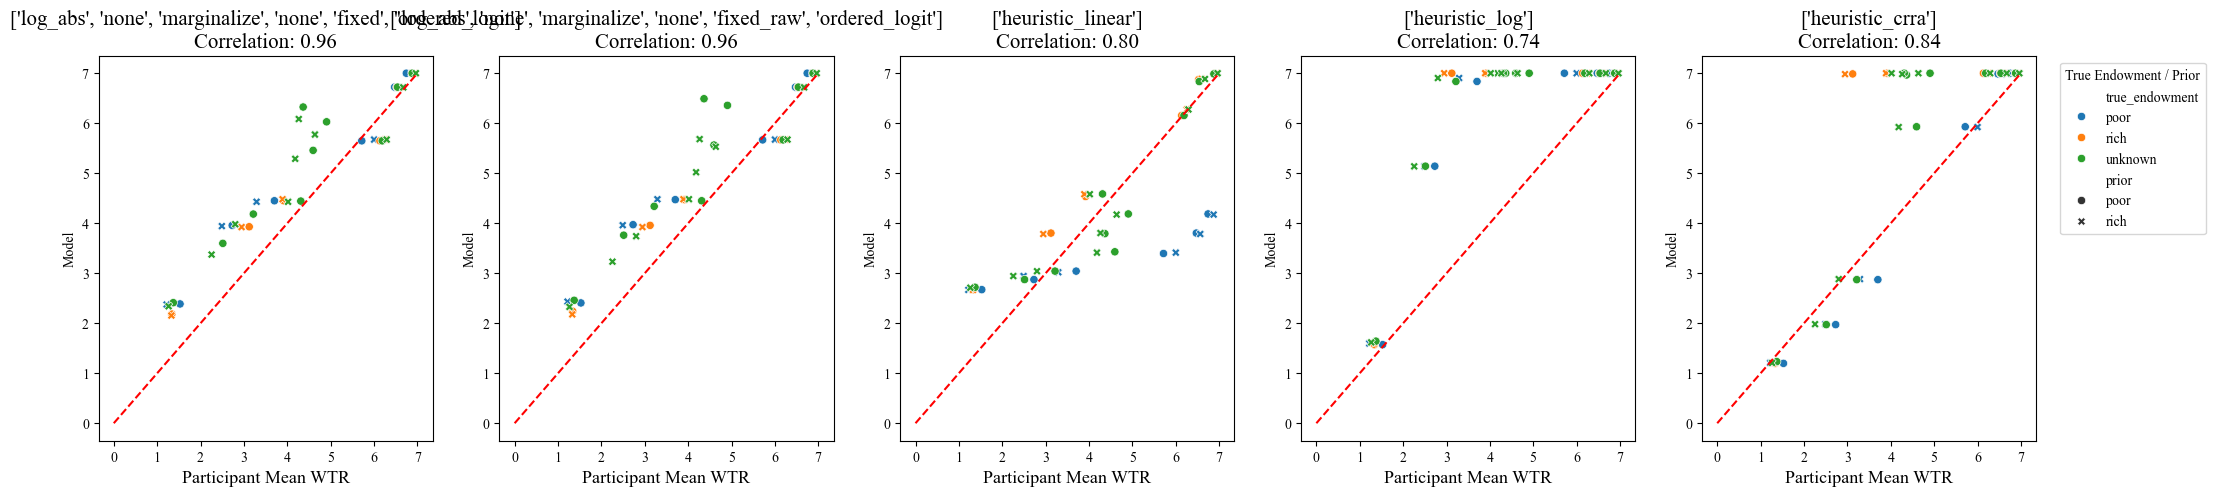

In [21]:


fig, axes = plt.subplots(1, len(selected_models), figsize=(len(selected_models) * 5, 5))


for i, name in enumerate(selected_models):
    df_means = predictions_means_df[name]
    ax = axes[i]

    corr = np.corrcoef(
        df_means['Model'],
        df_means['Participants']
    )[0, 1]

    ax.set_title(f'{name.split('__')}\nCorrelation: {corr:.2f}', size=15)
    

    sns.scatterplot(
        data=df_means.reset_index(),
        x='Participants',
        y='Model',
        hue='true_endowment',
        style='prior',
        ax=ax
    )
    # Plot a line on y=x
    max_val = max(df_means['Participants'].max(), df_means['Model'].max())
    ax.plot([0, max_val], [0, max_val], color='red', linestyle='--')
    ax.set_xlabel("Participant Mean WTR", size=13)  
    if i != axes.size - 1:
        ax.legend().remove()
    else:
        ax.legend(title='True Endowment / Prior', bbox_to_anchor=(1.05, 1), loc='upper left')

In [22]:

for name in selected_models:
    mcmc = results[name]
    posterior_samples = mcmc.get_samples()
    if "alpha_prior" not in posterior_samples:
        print(f"\n{name}")
        print("No alpha_prior in samples; skipping w(p) calculation.")
        continue
    print(f"\n{name}")
    
    alpha_samples = posterior_samples['alpha_prior']
    beta_samples = posterior_samples['beta_prior']
    w_02_samples = get_weighted_prob(0.2, alpha_samples, beta_samples)
    w_02_mean = w_02_samples.mean()
    w_02_hdi = az.hdi(np.array(w_02_samples), hdi_prob=0.95)
    print(f"w(0.2) mean: {w_02_mean:.2f}, 95% HDI: [{w_02_hdi[0]:.2f}, {w_02_hdi[1]:.2f}]")

    w_08_samples = get_weighted_prob(0.8, alpha_samples, beta_samples)
    w_08_mean = w_08_samples.mean()
    w_08_hdi = az.hdi(np.array(w_08_samples), hdi_prob=0.95)
    print(f"w(0.8) mean: {w_08_mean:.2f}, 95% HDI: [{w_08_hdi[0]:.2f}, {w_08_hdi[1]:.2f}]")




log_abs__none__marginalize__none__fixed__ordered_logit
w(0.2) mean: 0.41, 95% HDI: [0.35, 0.47]
w(0.8) mean: 0.61, 95% HDI: [0.54, 0.67]

log_abs__none__marginalize__none__fixed_raw__ordered_logit
No alpha_prior in samples; skipping w(p) calculation.

heuristic_linear
No alpha_prior in samples; skipping w(p) calculation.

heuristic_log
No alpha_prior in samples; skipping w(p) calculation.

heuristic_crra
No alpha_prior in samples; skipping w(p) calculation.


In [23]:

RATINGS = np.arange(1, 8)
 
 
def _rating_cols_for(df):
    """Return the rating column labels present in df: integers 1..7 or strings '1'..'7'."""
    int_cols = list(range(1, 8))
    str_cols = [str(i) for i in int_cols]
    if all(c in df.columns for c in int_cols):
        return int_cols
    if all(c in df.columns for c in str_cols):
        return str_cols
    raise KeyError(
        f"DataFrame is missing rating columns. Expected {int_cols} or {str_cols}, "
        f"got {list(df.columns)}"
    )
 
 
# Kept for backward compatibility (assumes string columns)
RATING_COLS = [str(i) for i in range(1, 8)]
 
CONDITION_ORDER = [
    ('poor',    'poor'), ('rich',    'poor'), ('unknown', 'poor'),
    ('poor',    'rich'), ('rich',    'rich'), ('unknown', 'rich'),
]
 
 
def _normalize_df(df):
    """Accept either a DataFrame with columns true_endowment/prior/donation_amount
    or one where those are in the index. Returns a flat-columns version."""
    needed = ['true_endowment', 'prior', 'donation_amount']
    if all(c in df.columns for c in needed):
        return df
    # Some or all of these are in the index — reset it
    reset = df.reset_index()
    missing = [c for c in needed if c not in reset.columns]
    if missing:
        raise KeyError(
            f"DataFrame is missing required columns {missing}. "
            f"Available columns: {list(reset.columns)}"
        )
    return reset
 
 
def _mean_rating(df):
    df = _normalize_df(df).copy()
    cols = _rating_cols_for(df)
    probs = df[cols].values
    probs = probs / probs.sum(axis=1, keepdims=True)
    df['mean_rating'] = (probs * RATINGS).sum(axis=1)
    return df
 
 
def _styles_from_comparison(models_dict, comparison_df,
                            rank_col='rank',
                            elpd_diff_col='elpd_diff',
                            weight_col='weight',
                            cmap_name='viridis'):
    """Build per-model matplotlib kwargs from an arviz comparison DataFrame.
 
    Best model (rank 0) gets bright, thick, solid. Worse models get progressively
    more muted, thinner, and dashed/dotted if notably worse.
    """
    cmap = plt.get_cmap(cmap_name)
    styles = {}
    n_models = len(models_dict)
 
    comp = comparison_df.loc[
        [m for m in models_dict.keys() if m in comparison_df.index]
    ].copy()
 
    if len(comp) == 0:
        cmap_tab = plt.get_cmap('tab10')
        return {
            name: dict(color=cmap_tab(i % 10), linewidth=1.8, alpha=0.9,
                       linestyle='-', label=name)
            for i, name in enumerate(models_dict.keys())
        }
 
    max_rank = comp[rank_col].max() if rank_col in comp.columns else n_models - 1
    max_rank = max(max_rank, 1)
 
    for name in models_dict.keys():
        if name not in comp.index:
            styles[name] = dict(color='gray', linewidth=1.0, alpha=0.3,
                                linestyle=':', label=f'{name} (no WAIC)')
            continue
 
        row = comp.loc[name]
        rank = int(row[rank_col]) if rank_col in comp.columns else 0
        elpd_diff = float(row[elpd_diff_col]) if elpd_diff_col in comp.columns else 0.0
        weight = float(row[weight_col]) if weight_col in comp.columns else 1.0 / n_models
 
        color_pos = rank / max_rank
        color = cmap(0.15 + 0.55 * color_pos)
        lw = 2.5 - 1.3 * color_pos
        alpha = 0.4 + 0.55 * np.clip(weight, 0, 1)
        if rank == 0:
            alpha = 1.0
 
        linestyle = '-'
        if elpd_diff < -4:
            linestyle = '--'
        if elpd_diff < -10:
            linestyle = ':'
 
        if rank == 0:
            label = f'{name} (best)'
        else:
            label = f'{name} (ΔELPD={elpd_diff:+.1f})'
 
        styles[name] = dict(
            color=color, linewidth=lw, alpha=alpha,
            linestyle=linestyle, label=label,
        )
 
    return styles
 
 
def plot_conditions(participants_df, models_dict,
                    comparison_df=None,
                    figsize=(15, 8),
                    participant_style=None,
                    model_styles=None,
                    highlight_dip=True,
                    ylim=(0.5, 7.5),
                    title=None,
                    save_path=None,
                    cmap_name='viridis'):
    """Plot mean ratings across all 6 conditions for participants vs multiple models.
 
    Parameters
    ----------
    participants_df : pd.DataFrame
    models_dict : dict[str, pd.DataFrame]
    comparison_df : pd.DataFrame or None
        Result of az.compare(...). If given, styles models by WAIC rank.
        Overridden if model_styles is explicitly provided.
    figsize, participant_style, model_styles, highlight_dip, ylim, title, save_path
        Usual plotting kwargs.
    cmap_name : str
        Colormap for rank-based coloring.
 
    Returns
    -------
    fig, axes
    """
    participant_style = participant_style or dict(
        color='black', marker='o', markersize=9, linewidth=2.5,
        label='Participants', zorder=10,
    )
 
    if model_styles is None:
        if comparison_df is not None:
            model_styles = _styles_from_comparison(
                models_dict, comparison_df, cmap_name=cmap_name
            )
        else:
            cmap_tab = plt.get_cmap('tab10')
            model_styles = {
                name: dict(color=cmap_tab(i % 10), linewidth=1.8, alpha=0.9,
                           linestyle='-', label=name)
                for i, name in enumerate(models_dict.keys())
            }
 
    # Plot order: worst first so best ends up visually on top
    if comparison_df is not None and 'rank' in comparison_df.columns:
        plot_order = sorted(
            models_dict.keys(),
            key=lambda n: -int(comparison_df.loc[n, 'rank'])
                if n in comparison_df.index else -999
        )
    else:
        plot_order = list(models_dict.keys())
 
    p_df = _mean_rating(participants_df)
    m_dfs = {name: _mean_rating(df) for name, df in models_dict.items()}
 
    fig, axes = plt.subplots(2, 3, figsize=figsize, sharey=True)
 
    for idx, (te, pr) in enumerate(CONDITION_ORDER):
        ax = axes[idx // 3, idx % 3]
 
        p_sub = p_df[(p_df['true_endowment'] == te) & (p_df['prior'] == pr)]
        p_sub = p_sub.sort_values('donation_amount')
 
        if len(p_sub) > 0:
            x_min = p_sub['donation_amount'].min()
            x_max = p_sub['donation_amount'].max()
        else:
            x_min, x_max = 0, 100
 
        for name in plot_order:
            m_df = m_dfs[name]
            m_sub = m_df[(m_df['true_endowment'] == te) & (m_df['prior'] == pr)]
            m_sub = m_sub.sort_values('donation_amount')
            m_sub = m_sub[(m_sub['donation_amount'] >= x_min) &
                          (m_sub['donation_amount'] <= x_max)]
            if len(m_sub) > 0:
                ax.plot(m_sub['donation_amount'], m_sub['mean_rating'],
                        **model_styles[name])
 
        if len(p_sub) > 0:
            ax.plot(p_sub['donation_amount'], p_sub['mean_rating'],
                    **participant_style)
 
        if highlight_dip and x_max >= 25:
            ax.axvspan(20, 25, alpha=0.08, color='red')
        ax.set_xlabel('Donation amount')
        if idx % 3 == 0:
            ax.set_ylabel('Rating (1-7)')
        ax.set_title(f"true={te}, prior={pr}")
        ax.set_ylim(*ylim)
        ax.set_xlim(x_min - 1, x_max + 1)
        ax.grid(alpha=0.3)
        if idx == 0:
            ax.legend(fontsize=7, loc='lower right')
 
    if title:
        plt.suptitle(title, fontsize=13)
    plt.tight_layout()
 
    if save_path:
        plt.savefig(save_path, dpi=110, bbox_inches='tight')
 
    return fig, axes

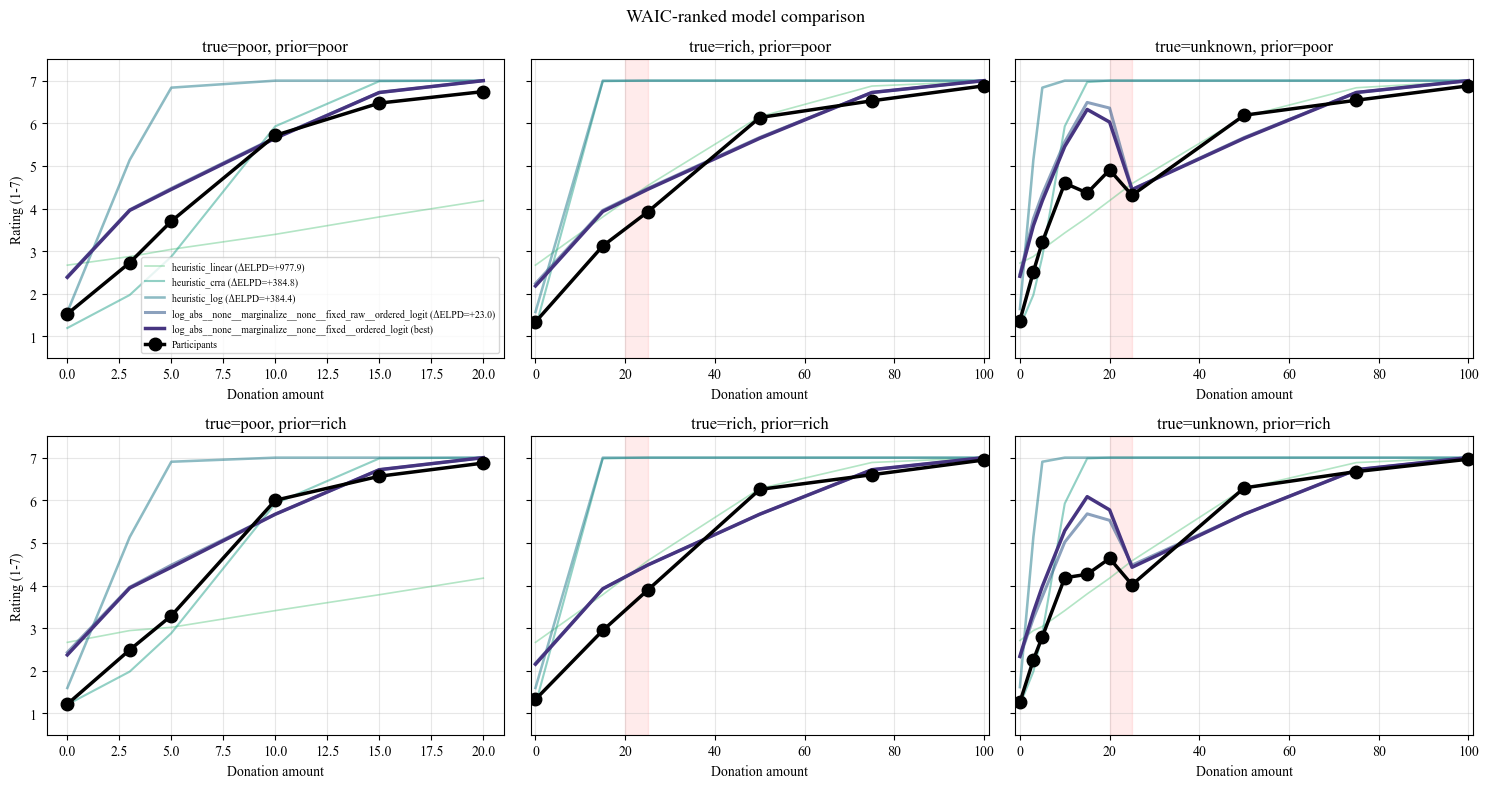

In [24]:
fig, axes = plot_conditions(
    df_probs, {name: df for name, df in predictions_df.items() if name in selected_models},
    comparison_df=comparison,
    title='WAIC-ranked model comparison',
    save_path=None,
)

# Mixture vs marginalize

In [21]:
selected_models = comp_cases['mix_vs_marg']
selected_az = {k: v for k, v in results_az.items() if k in selected_models}
comparison = az.compare(selected_az, ic='waic')
display(comparison)

for name in selected_models:
    print(f"\n{name}")
    # Do not show cutpoints and gap_props for cleaner output
    display(az.summary(results_az[name], var_names=[v for v in results_az[name].posterior.data_vars if v not in ('cutpoints', 'gap_props')]))

See http://arxiv.org/abs/1507.04544 for details
See http://arxiv.org/abs/1507.04544 for details
See http://arxiv.org/abs/1507.04544 for details


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
log_abs__none__marginalize__none__trust__ordered_logit,0,-732.964215,43.278759,0.000000,7.540907e-01,57.563050,0.000000,True,log
log_abs__none__marginalize__none__fixed__ordered_logit,1,-745.710478,44.366096,12.746263,2.459093e-01,58.718022,8.983709,True,log
log_abs__none__mixture__none__fixed__ordered_logit,2,-929.824568,261.719391,196.860353,2.727307e-11,90.764199,61.191764,True,log



log_abs__none__marginalize__none__fixed__ordered_logit


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_prior,0.296,0.105,0.100,0.468,0.002,0.001,2229.0,991.0,1.0
beta_prior,0.773,0.030,0.719,0.823,0.001,0.000,2229.0,991.0,1.0
inv_temp,124.227,20.837,85.287,161.789,0.515,0.364,1630.0,2349.0,1.0
lambda,-0.551,0.073,-0.685,-0.414,0.001,0.001,2500.0,2944.0,1.0
lambda_sd,0.566,0.020,0.529,0.605,0.000,0.000,1963.0,2616.0,1.0
log_inv_temp,4.808,0.168,4.487,5.114,0.004,0.003,1630.0,2349.0,1.0
log_scale,0.992,0.257,0.548,1.514,0.006,0.005,1579.0,2208.0,1.0
scale,0.727,0.050,0.634,0.820,0.001,0.001,1579.0,2208.0,1.0



log_abs__none__marginalize__none__trust__ordered_logit


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
default_p_rich,0.881,0.061,0.770,0.987,0.001,0.001,3288.0,2215.0,1.0
effective_priors[0],0.709,0.074,0.568,0.840,0.001,0.001,3837.0,2874.0,1.0
effective_priors[1],0.859,0.045,0.772,0.937,0.001,0.001,3500.0,2695.0,1.0
inv_temp,172.782,29.578,119.506,229.111,0.657,0.465,1980.0,2249.0,1.0
lambda,-0.496,0.077,-0.645,-0.362,0.001,0.001,3062.0,3017.0,1.0
lambda_sd,0.579,0.027,0.532,0.630,0.001,0.000,2822.0,3088.0,1.0
log_inv_temp,5.137,0.173,4.824,5.467,0.004,0.003,1980.0,2249.0,1.0
log_scale,1.271,0.238,0.819,1.723,0.005,0.004,2226.0,2367.0,1.0
prior_trust,0.250,0.102,0.068,0.443,0.002,0.001,3496.0,1884.0,1.0
scale,0.778,0.041,0.701,0.854,0.001,0.001,2226.0,2367.0,1.0



log_abs__none__mixture__none__fixed__ordered_logit


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_prior,0.801,0.356,0.112,1.393,0.016,0.013,601.0,1237.0,1.01
beta_prior,0.938,0.125,0.722,1.155,0.006,0.004,601.0,1237.0,1.01
inv_temp,159.914,92.055,4.795,252.111,44.343,33.762,7.0,27.0,1.53
lambda,-0.163,0.544,-0.638,0.920,0.266,0.203,7.0,26.0,1.53
lambda_sd,0.690,0.207,0.517,1.105,0.101,0.077,7.0,30.0,1.53
log_inv_temp,4.465,1.527,1.709,5.574,0.758,0.580,7.0,27.0,1.53
log_scale,0.269,2.135,-3.723,1.852,1.059,0.810,7.0,30.0,1.53
mix_weight_poor,0.012,0.013,0.000,0.038,0.006,0.004,7.0,27.0,1.53
scale,0.619,0.340,0.021,0.859,0.169,0.129,7.0,30.0,1.53


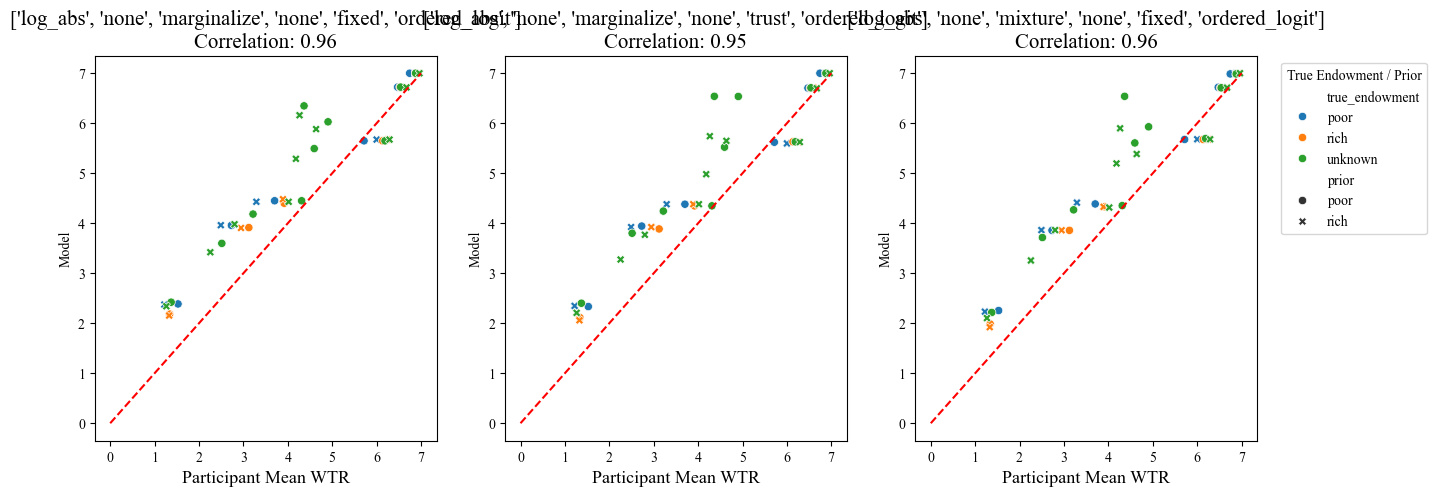

In [196]:


fig, axes = plt.subplots(1, len(selected_models), figsize=(len(selected_models) * 5, 5))


for i, name in enumerate(selected_models):
    df_means = predictions_means_df[name]
    ax = axes[i]

    corr = np.corrcoef(
        df_means['Model'],
        df_means['Participants']
    )[0, 1]

    ax.set_title(f'{name.split('__')}\nCorrelation: {corr:.2f}', size=15)
    

    sns.scatterplot(
        data=df_means.reset_index(),
        x='Participants',
        y='Model',
        hue='true_endowment',
        style='prior',
        ax=ax
    )
    # Plot a line on y=x
    max_val = max(df_means['Participants'].max(), df_means['Model'].max())
    ax.plot([0, max_val], [0, max_val], color='red', linestyle='--')
    ax.set_xlabel("Participant Mean WTR", size=13)  
    if i != axes.size - 1:
        ax.legend().remove()
    else:
        ax.legend(title='True Endowment / Prior', bbox_to_anchor=(1.05, 1), loc='upper left')

In [104]:

for name in selected_models:
    mcmc = results[name]
    posterior_samples = mcmc.get_samples()
    if "alpha_prior" not in posterior_samples:
        print(f"\n{name}")
        print("No alpha_prior in samples; skipping w(p) calculation.")
        continue
    print(f"\n{name}")
    
    alpha_samples = posterior_samples['alpha_prior']
    beta_samples = posterior_samples['beta_prior']
    w_02_samples = get_weighted_prob(0.2, alpha_samples, beta_samples)
    w_02_mean = w_02_samples.mean()
    w_02_hdi = az.hdi(np.array(w_02_samples), hdi_prob=0.95)
    print(f"w(0.2) mean: {w_02_mean:.2f}, 95% HDI: [{w_02_hdi[0]:.2f}, {w_02_hdi[1]:.2f}]")

    w_08_samples = get_weighted_prob(0.8, alpha_samples, beta_samples)
    w_08_mean = w_08_samples.mean()
    w_08_hdi = az.hdi(np.array(w_08_samples), hdi_prob=0.95)
    print(f"w(0.8) mean: {w_08_mean:.2f}, 95% HDI: [{w_08_hdi[0]:.2f}, {w_08_hdi[1]:.2f}]")




log_abs__none__marginalize__none__fixed__ordered_logit
w(0.2) mean: 0.41, 95% HDI: [0.35, 0.47]
w(0.8) mean: 0.61, 95% HDI: [0.54, 0.67]

log_abs__none__marginalize__none__trust__ordered_logit
No alpha_prior in samples; skipping w(p) calculation.

log_abs__none__mixture__none__fixed__ordered_logit
w(0.2) mean: 0.26, 95% HDI: [0.09, 0.46]
w(0.8) mean: 0.74, 95% HDI: [0.58, 0.89]


In [105]:

RATINGS = np.arange(1, 8)
 
 
def _rating_cols_for(df):
    """Return the rating column labels present in df: integers 1..7 or strings '1'..'7'."""
    int_cols = list(range(1, 8))
    str_cols = [str(i) for i in int_cols]
    if all(c in df.columns for c in int_cols):
        return int_cols
    if all(c in df.columns for c in str_cols):
        return str_cols
    raise KeyError(
        f"DataFrame is missing rating columns. Expected {int_cols} or {str_cols}, "
        f"got {list(df.columns)}"
    )
 
 
# Kept for backward compatibility (assumes string columns)
RATING_COLS = [str(i) for i in range(1, 8)]
 
CONDITION_ORDER = [
    ('poor',    'poor'), ('rich',    'poor'), ('unknown', 'poor'),
    ('poor',    'rich'), ('rich',    'rich'), ('unknown', 'rich'),
]
 
 
def _normalize_df(df):
    """Accept either a DataFrame with columns true_endowment/prior/donation_amount
    or one where those are in the index. Returns a flat-columns version."""
    needed = ['true_endowment', 'prior', 'donation_amount']
    if all(c in df.columns for c in needed):
        return df
    # Some or all of these are in the index — reset it
    reset = df.reset_index()
    missing = [c for c in needed if c not in reset.columns]
    if missing:
        raise KeyError(
            f"DataFrame is missing required columns {missing}. "
            f"Available columns: {list(reset.columns)}"
        )
    return reset
 
 
def _mean_rating(df):
    df = _normalize_df(df).copy()
    cols = _rating_cols_for(df)
    probs = df[cols].values
    probs = probs / probs.sum(axis=1, keepdims=True)
    df['mean_rating'] = (probs * RATINGS).sum(axis=1)
    return df
 
 
def _styles_from_comparison(models_dict, comparison_df,
                            rank_col='rank',
                            elpd_diff_col='elpd_diff',
                            weight_col='weight',
                            cmap_name='viridis'):
    """Build per-model matplotlib kwargs from an arviz comparison DataFrame.
 
    Best model (rank 0) gets bright, thick, solid. Worse models get progressively
    more muted, thinner, and dashed/dotted if notably worse.
    """
    cmap = plt.get_cmap(cmap_name)
    styles = {}
    n_models = len(models_dict)
 
    comp = comparison_df.loc[
        [m for m in models_dict.keys() if m in comparison_df.index]
    ].copy()
 
    if len(comp) == 0:
        cmap_tab = plt.get_cmap('tab10')
        return {
            name: dict(color=cmap_tab(i % 10), linewidth=1.8, alpha=0.9,
                       linestyle='-', label=name)
            for i, name in enumerate(models_dict.keys())
        }
 
    max_rank = comp[rank_col].max() if rank_col in comp.columns else n_models - 1
    max_rank = max(max_rank, 1)
 
    for name in models_dict.keys():
        if name not in comp.index:
            styles[name] = dict(color='gray', linewidth=1.0, alpha=0.3,
                                linestyle=':', label=f'{name} (no WAIC)')
            continue
 
        row = comp.loc[name]
        rank = int(row[rank_col]) if rank_col in comp.columns else 0
        elpd_diff = float(row[elpd_diff_col]) if elpd_diff_col in comp.columns else 0.0
        weight = float(row[weight_col]) if weight_col in comp.columns else 1.0 / n_models
 
        color_pos = rank / max_rank
        color = cmap(0.15 + 0.55 * color_pos)
        lw = 2.5 - 1.3 * color_pos
        alpha = 0.4 + 0.55 * np.clip(weight, 0, 1)
        if rank == 0:
            alpha = 1.0
 
        linestyle = '-'
        if elpd_diff < -4:
            linestyle = '--'
        if elpd_diff < -10:
            linestyle = ':'
 
        if rank == 0:
            label = f'{name} (best)'
        else:
            label = f'{name} (ΔELPD={elpd_diff:+.1f})'
 
        styles[name] = dict(
            color=color, linewidth=lw, alpha=alpha,
            linestyle=linestyle, label=label,
        )
 
    return styles
 
 
def plot_conditions(participants_df, models_dict,
                    comparison_df=None,
                    figsize=(15, 8),
                    participant_style=None,
                    model_styles=None,
                    highlight_dip=True,
                    ylim=(0.5, 7.5),
                    title=None,
                    save_path=None,
                    cmap_name='viridis'):
    """Plot mean ratings across all 6 conditions for participants vs multiple models.
 
    Parameters
    ----------
    participants_df : pd.DataFrame
    models_dict : dict[str, pd.DataFrame]
    comparison_df : pd.DataFrame or None
        Result of az.compare(...). If given, styles models by WAIC rank.
        Overridden if model_styles is explicitly provided.
    figsize, participant_style, model_styles, highlight_dip, ylim, title, save_path
        Usual plotting kwargs.
    cmap_name : str
        Colormap for rank-based coloring.
 
    Returns
    -------
    fig, axes
    """
    participant_style = participant_style or dict(
        color='black', marker='o', markersize=9, linewidth=2.5,
        label='Participants', zorder=10,
    )
 
    if model_styles is None:
        if comparison_df is not None:
            model_styles = _styles_from_comparison(
                models_dict, comparison_df, cmap_name=cmap_name
            )
        else:
            cmap_tab = plt.get_cmap('tab10')
            model_styles = {
                name: dict(color=cmap_tab(i % 10), linewidth=1.8, alpha=0.9,
                           linestyle='-', label=name)
                for i, name in enumerate(models_dict.keys())
            }
 
    # Plot order: worst first so best ends up visually on top
    if comparison_df is not None and 'rank' in comparison_df.columns:
        plot_order = sorted(
            models_dict.keys(),
            key=lambda n: -int(comparison_df.loc[n, 'rank'])
                if n in comparison_df.index else -999
        )
    else:
        plot_order = list(models_dict.keys())
 
    p_df = _mean_rating(participants_df)
    m_dfs = {name: _mean_rating(df) for name, df in models_dict.items()}
 
    fig, axes = plt.subplots(2, 3, figsize=figsize, sharey=True)
 
    for idx, (te, pr) in enumerate(CONDITION_ORDER):
        ax = axes[idx // 3, idx % 3]
 
        p_sub = p_df[(p_df['true_endowment'] == te) & (p_df['prior'] == pr)]
        p_sub = p_sub.sort_values('donation_amount')
 
        if len(p_sub) > 0:
            x_min = p_sub['donation_amount'].min()
            x_max = p_sub['donation_amount'].max()
        else:
            x_min, x_max = 0, 100
 
        for name in plot_order:
            m_df = m_dfs[name]
            m_sub = m_df[(m_df['true_endowment'] == te) & (m_df['prior'] == pr)]
            m_sub = m_sub.sort_values('donation_amount')
            m_sub = m_sub[(m_sub['donation_amount'] >= x_min) &
                          (m_sub['donation_amount'] <= x_max)]
            if len(m_sub) > 0:
                ax.plot(m_sub['donation_amount'], m_sub['mean_rating'],
                        **model_styles[name])
 
        if len(p_sub) > 0:
            ax.plot(p_sub['donation_amount'], p_sub['mean_rating'],
                    **participant_style)
 
        if highlight_dip and x_max >= 25:
            ax.axvspan(20, 25, alpha=0.08, color='red')
        ax.set_xlabel('Donation amount')
        if idx % 3 == 0:
            ax.set_ylabel('Rating (1-7)')
        ax.set_title(f"true={te}, prior={pr}")
        ax.set_ylim(*ylim)
        ax.set_xlim(x_min - 1, x_max + 1)
        ax.grid(alpha=0.3)
        if idx == 0:
            ax.legend(fontsize=7, loc='lower right')
 
    if title:
        plt.suptitle(title, fontsize=13)
    plt.tight_layout()
 
    if save_path:
        plt.savefig(save_path, dpi=110, bbox_inches='tight')
 
    return fig, axes

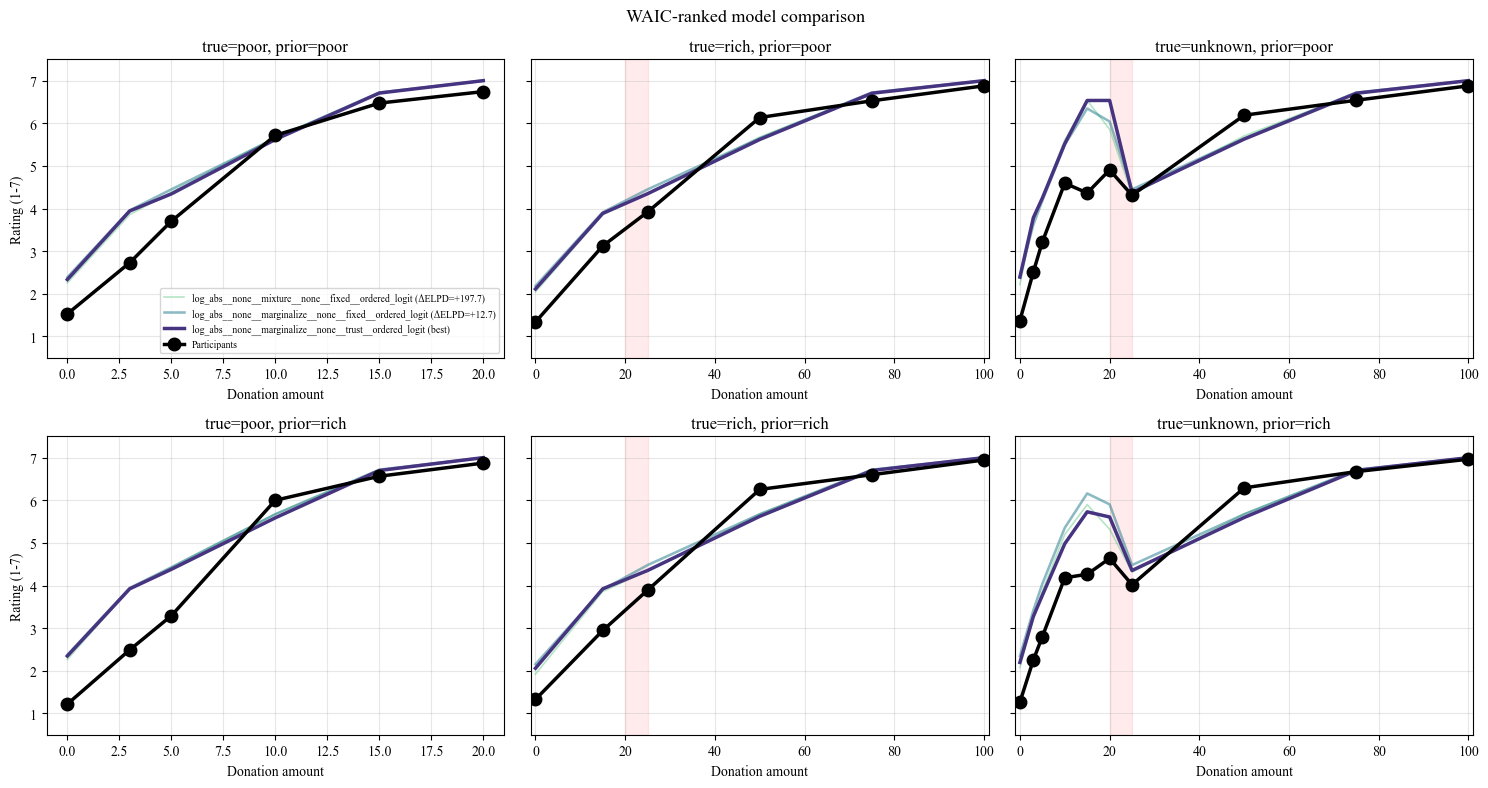

In [106]:
fig, axes = plot_conditions(
    df_probs, {name: df for name, df in predictions_df.items() if name in selected_models},
    comparison_df=comparison,
    title='WAIC-ranked model comparison',
    save_path='comparison.png',
)

# Naive vs signal

In [107]:
selected_models = comp_cases['naive_vs_signal']
selected_az = {k: v for k, v in results_az.items() if k in selected_models}
comparison = az.compare(selected_az, ic='waic')
display(comparison)

for name in selected_models:
    print(f"\n{name}")
    # Do not show cutpoints and gap_props for cleaner output
    display(az.summary(results_az[name], var_names=[v for v in results_az[name].posterior.data_vars if v not in ('cutpoints', 'gap_props')]))

See http://arxiv.org/abs/1507.04544 for details
See http://arxiv.org/abs/1507.04544 for details


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
log_abs__none__marginalize__none__trust__ordered_logit,0,-732.570205,42.889179,0.000000,1.0,57.498596,0.000000,True,log
log_abs__none__mixture__none__fixed__ordered_logit,1,-930.317364,262.437653,197.747159,0.0,90.998191,61.443189,True,log



log_abs__none__marginalize__none__trust__ordered_logit


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
default_p_rich,0.880,0.061,0.773,0.989,0.001,0.001,3577.0,2182.0,1.0
effective_priors[0],0.709,0.073,0.582,0.847,0.001,0.001,4454.0,3102.0,1.0
effective_priors[1],0.859,0.045,0.775,0.936,0.001,0.000,3892.0,3237.0,1.0
inv_temp,173.498,29.821,120.856,232.067,0.692,0.489,1821.0,2314.0,1.0
lambda,-0.497,0.075,-0.633,-0.351,0.001,0.001,2920.0,3301.0,1.0
lambda_sd,0.579,0.027,0.531,0.629,0.001,0.000,2768.0,3068.0,1.0
log_inv_temp,5.141,0.174,4.821,5.469,0.004,0.003,1821.0,2314.0,1.0
log_scale,1.274,0.241,0.840,1.748,0.005,0.004,1969.0,2491.0,1.0
prior_trust,0.250,0.100,0.070,0.439,0.002,0.001,3467.0,1851.0,1.0
scale,0.779,0.041,0.700,0.853,0.001,0.001,1969.0,2491.0,1.0



log_abs__none__mixture__none__fixed__ordered_logit


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_prior,0.804,0.354,0.151,1.420,0.017,0.016,961.0,1460.0,1.01
beta_prior,0.939,0.125,0.722,1.152,0.007,0.005,961.0,1460.0,1.01
inv_temp,159.764,92.056,4.853,252.840,44.301,33.725,7.0,32.0,1.53
lambda,-0.165,0.543,-0.636,0.919,0.265,0.202,7.0,28.0,1.53
lambda_sd,0.690,0.207,0.513,1.100,0.100,0.077,7.0,29.0,1.53
log_inv_temp,4.464,1.527,1.701,5.570,0.758,0.580,7.0,32.0,1.53
log_scale,0.268,2.136,-3.711,1.855,1.059,0.810,7.0,27.0,1.53
mix_weight_poor,0.012,0.013,0.000,0.038,0.006,0.004,7.0,34.0,1.53
scale,0.619,0.340,0.020,0.857,0.169,0.129,7.0,27.0,1.53



log_abs__identity_poor__marginalize__none__trust__ordered_logit


KeyError: 'log_abs__identity_poor__marginalize__none__trust__ordered_logit'

KeyError: 'log_abs__identity_poor__marginalize__none__trust__ordered_logit'

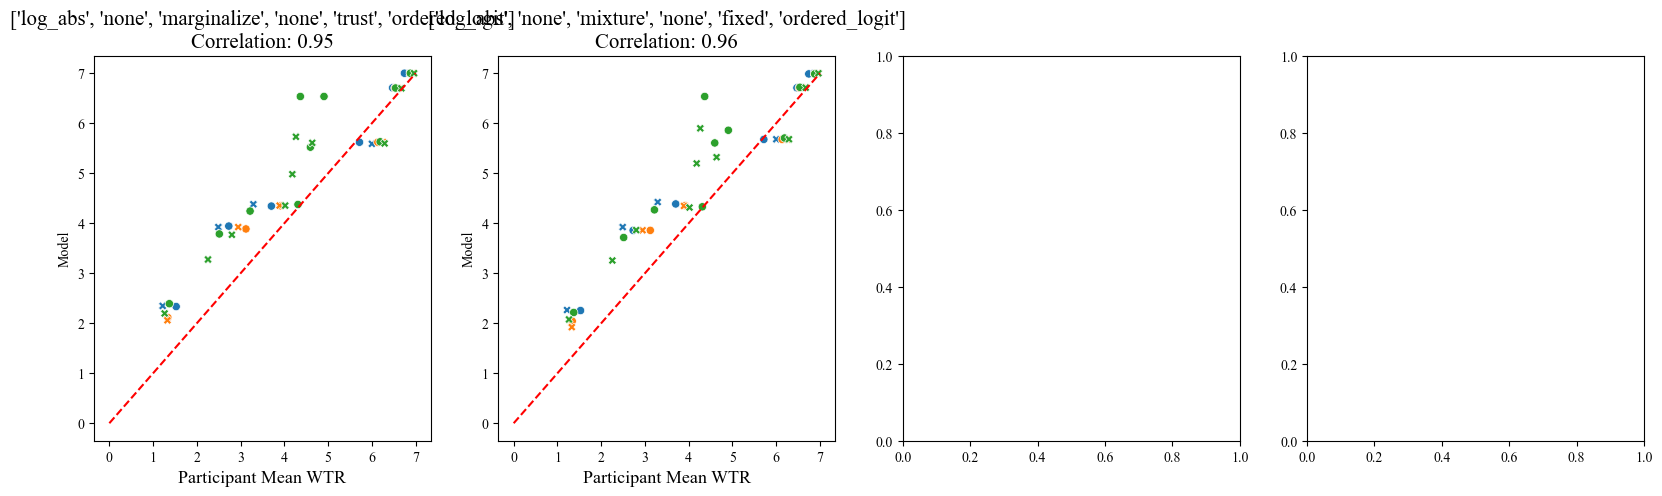

In [108]:


fig, axes = plt.subplots(1, len(selected_models), figsize=(len(selected_models) * 5, 5))


for i, name in enumerate(selected_models):
    df_means = predictions_means_df[name]
    ax = axes[i]

    corr = np.corrcoef(
        df_means['Model'],
        df_means['Participants']
    )[0, 1]

    ax.set_title(f'{name.split('__')}\nCorrelation: {corr:.2f}', size=15)
    

    sns.scatterplot(
        data=df_means.reset_index(),
        x='Participants',
        y='Model',
        hue='true_endowment',
        style='prior',
        ax=ax
    )
    # Plot a line on y=x
    max_val = max(df_means['Participants'].max(), df_means['Model'].max())
    ax.plot([0, max_val], [0, max_val], color='red', linestyle='--')
    ax.set_xlabel("Participant Mean WTR", size=13)  
    if i != axes.size - 1:
        ax.legend().remove()
    else:
        ax.legend(title='True Endowment / Prior', bbox_to_anchor=(1.05, 1), loc='upper left')

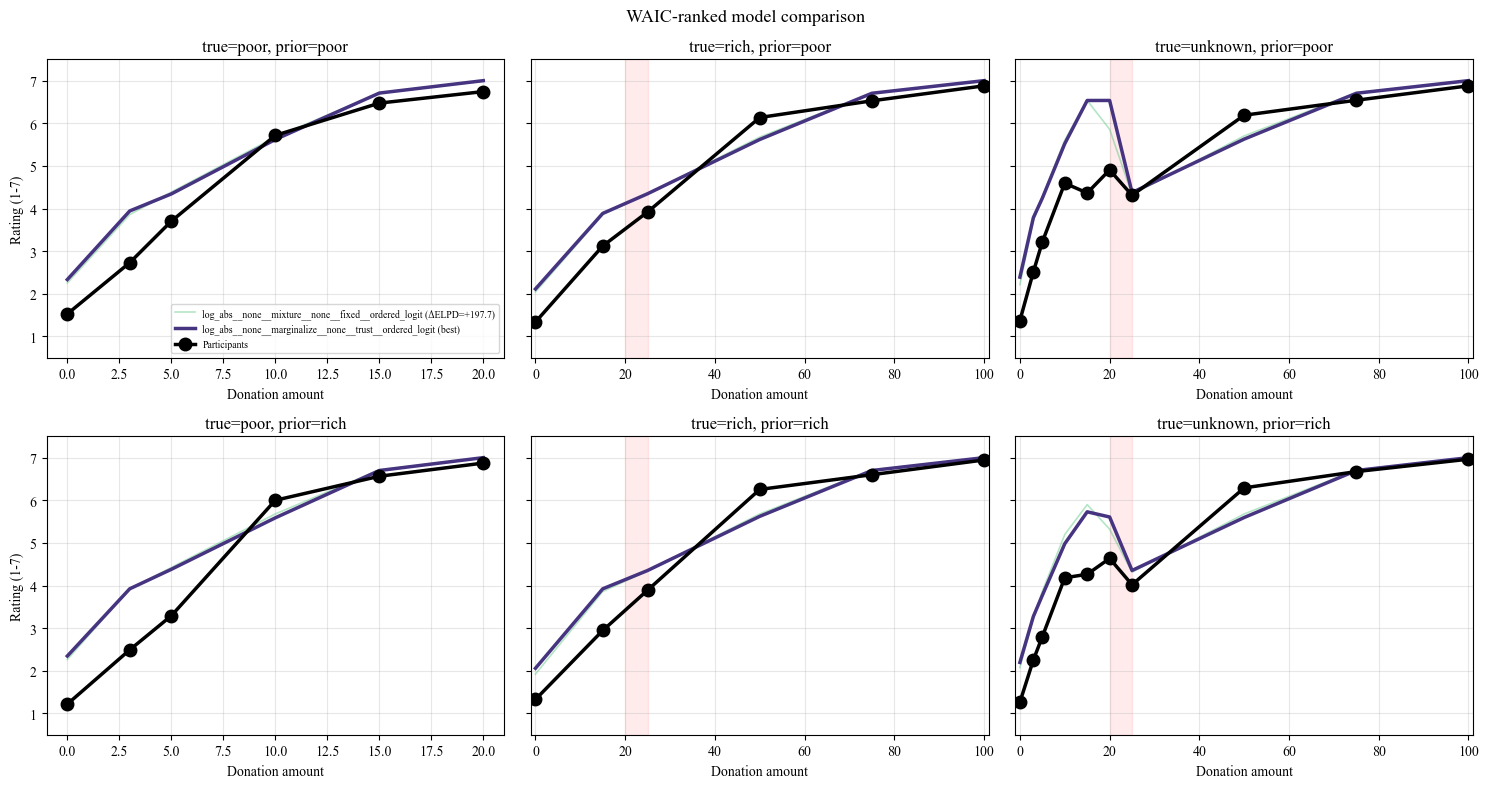

In [109]:
fig, axes = plot_conditions(
    df_probs, {name: df for name, df in predictions_df.items() if name in selected_models},
    comparison_df=comparison,
    title='WAIC-ranked model comparison',
    save_path='comparison.png',
)